In [2]:
from nba_api.stats.endpoints import playerdashptpass

In [3]:
from nba_api.stats.static import teams, players
from nba_api.stats.endpoints import commonteamroster

In [4]:
players.find_players_by_full_name('LeBron James')
teams.find_teams_by_city('Los Angeles')

lakers = commonteamroster.CommonTeamRoster(season='2024-25', team_id=1610612747).get_data_frames()[0]

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

Pulling in spatial data by number of shots at different parts of the court. Edges would be the proportion of their total shots taken at each part of the court bins specified.

In [6]:
from nba_api.stats.endpoints import leaguedashplayershotlocations
import pandas as pd

In [6]:
shots_24 = leaguedashplayershotlocations.LeagueDashPlayerShotLocations(season='2024-25', season_type_all_star='Regular Season').get_data_frames()[0]
shots_24.head()

SHOT_CATEGORY                                                               \
columns       PLAYER_ID    PLAYER_NAME     TEAM_ID TEAM_ABBREVIATION   AGE   
0               1630639    A.J. Lawson  1610612761               TOR  24.0   
1               1631260       AJ Green  1610612749               MIL  25.0   
2               1642358     AJ Johnson  1610612764               WAS  20.0   
3                203932   Aaron Gordon  1610612743               DEN  29.0   
4               1628988  Aaron Holiday  1610612745               HOU  28.0   

SHOT_CATEGORY          Restricted Area             In The Paint (Non-RA)  ...  \
columns       NICKNAME             FGM  FGA FG_PCT                   FGM  ...   
0                 A.J.              39   69  0.565                     7  ...   
1                   AJ               8   13  0.615                     6  ...   
2                   AJ              45   79  0.570                    12  ...   
3                Aaron             139  215  0.647                    24  ...   
4                Aaron              16   22  0.727                    18  ...   

SHOT_CATEGORY Right Corner 3 Above the Break 3             Backcourt       \
columns               FG_PCT               FGM  FGA FG_PCT       FGM  FGA   
0                      0.200                22   65  0.338       0.0  0.0   
1                      0.563                95  248  0.383       1.0  3.0   
2                      0.500                19   76  0.250       0.0  2.0   
3                      0.519                44  106  0.415       0.0  1.0   
4                      0.333                55  144  0.382       0.0  1.0   

SHOT_CATEGORY        Corner 3                
columns       FG_PCT      FGM    FGA FG_PCT  
0              0.000     11.0   36.0  0.306  
1              0.333     59.0  112.0  0.527  
2              0.000      5.0   12.0  0.417  
3              0.000     31.0   65.0  0.477  
4              0.000     17.0   36.0  0.472  

[5 rows x 30 columns]

In [28]:
shots_24.shape

(569, 30)

In [11]:
import numpy as np

shots_24 = leaguedashplayershotlocations.LeagueDashPlayerShotLocations(season='2024-25', season_type_all_star='Regular Season').get_data_frames()[0]

idx = pd.IndexSlice

df_values = np.array([])

unique_player_count = 0

for _, row in shots_24.iterrows():
    row_teamid = row.iloc[2]
    player_id = row.iloc[0]
    if row_teamid == 1610612747:
        unique_player_count += 1
        df_values = np.append(df_values, player_id)
        df_values = np.append(df_values, row.iloc[[7,8,10,11,13,14,16,17,19,20,22,23,25,26]])
        
    
df = pd.DataFrame(df_values.reshape(unique_player_count, -1), 
                      columns = ['player_id','restricited_area_att','restricited_area_pct',
                                 'in_the_paint_att','in_the_paint_pct','mid_range_att','mid_range_pct',
                                 'left_corner_att','left_corner_pct','right_corner_att','right_corner_pct',
                                 'above_break3_att','above_break3_pct','backcourt_att','backcourt_pct'])


pull the number of shot attempts at each of the shot locations for players on the lakers

In [11]:
df

,player_id,restricited_area_att,restricited_area_pct,in_the_paint_att,in_the_paint_pct,mid_range_att,mid_range_pct,left_corner_att,left_corner_pct,right_corner_att,right_corner_pct,above_break3_att,above_break3_pct,backcourt_att,backcourt_pct
0,203458.0,28,0.607,22,0.545,4.0,0.25,2.0,0.5,2.0,0.0,5,0.2,0.0,0.0
1,1642422,10,0.6,2,0.0,0.0,0.0,4.0,0.0,1.0,0.0,2,0.0,0.0,0.0
2,1630559,201,0.692,241,0.465,64.0,0.406,39.0,0.385,30.0,0.567,455,0.369,7.0,0.0
3,1642355,7,0.714,21,0.238,7.0,0.286,4.0,0.25,4.0,0.25,24,0.292,0.0,0.0
4,1629629,30,0.667,14,0.286,3.0,0.333,14.0,0.357,9.0,0.222,24,0.25,0.0,0.0
5,1631132,49,0.714,10,0.3,3.0,0.667,2.0,0.0,0.0,0.0,2,0.0,0.0,0.0
6,1642261,111,0.757,73,0.411,33.0,0.455,57.0,0.439,41.0,0.439,240,0.354,2.0,0.0
7,1627827,90,0.611,28,0.321,3.0,0.667,69.0,0.435,56.0,0.429,188,0.399,1.0,0.0
8,1629216,42,0.643,40,0.425,29.0,0.517,65.0,0.323,47.0,0.489,196,0.332,1.0,0.0
9,1629020,79,0.608,10,0.2,0.0,0.0,9.0,0.222,17.0,0.412,5,0.0,1.0,0.0


merge shot attempt and percentage values to passing dataframe to then use that to build out graph for each team each season

In [14]:
import time 

pass_row_inf = []
for _, row in lakers.iterrows():
    time.sleep(30)  # Sleep for 30 seconds to avoid rate limiting
    player_info = playerdashptpass.PlayerDashPtPass(team_id=1610612747, player_id=row['PLAYER_ID'], season='2024-25', season_type_all_star='Regular Season').get_data_frames()[0]
    for _, row in player_info.iterrows():
        row_inf = {'player_id': row['PLAYER_ID'], 'player_name': row['PLAYER_NAME_LAST_FIRST'],'pass_to_id': row['PASS_TEAMMATE_PLAYER_ID'],'pass_to': row['PASS_TO'], 'count': row['PASS'], 'proportion': row['FREQUENCY']}
        pass_row_inf.append(row_inf)
pass_df = pd.DataFrame(pass_row_inf)

(array([21., 18.,  0., 18.,  7., 22., 17., 29., 27., 21., 18., 20., 15.,
         9.,  9., 15., 10.,  2.,  1.,  2.]),
 array([0.        , 0.35442044, 0.70884088, 1.06326132, 1.41768176,
        1.77210219, 2.12652263, 2.48094307, 2.83536351, 3.18978395,
        3.54420439, 3.89862483, 4.25304527, 4.60746571, 4.96188615,
        5.31630658, 5.67072702, 6.02514746, 6.3795679 , 6.73398834,
        7.08840878]),
 <BarContainer object of 20 artists>)

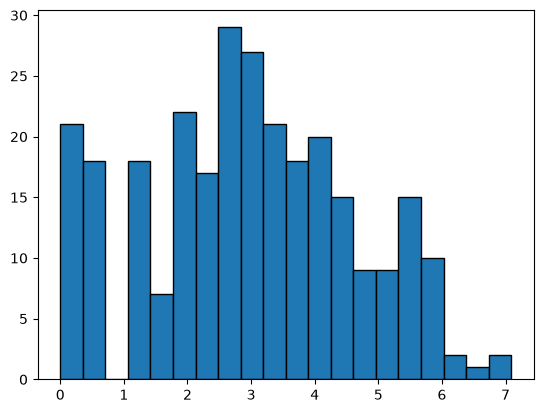

In [14]:
#plt.hist(pass_df['frequency'], bins=20, edgecolor='black')

pass_df['log_frequency'] = np.log(pass_df['count'])
plt.hist(pass_df['log_frequency'], bins=20, edgecolor='black')

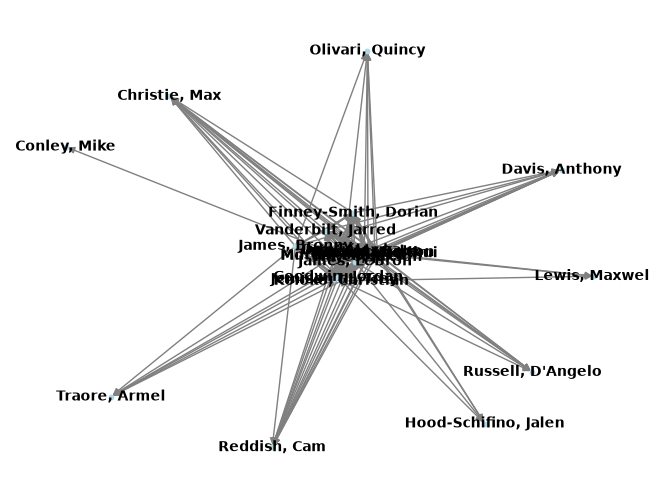

In [12]:
G = nx.DiGraph()

for _, row in pass_df.iterrows():
    G.add_edge(row['player_name'], row['pass_to'], weight=row['log_frequency'])
nx.draw(G, with_labels=True, node_size=10, node_color='lightblue', font_size=10, font_weight='bold', edge_color='gray')
plt.show()

In [15]:
#dropping Mike Conley from the graph since he never player on the Lakers or with these collection of players in the 24-25 season
pass_df = pass_df.drop(pass_df[pass_df['pass_to'] == "Conley, Mike"].index)

In [24]:
weights = [d["weight"] for _, _, d in G.edges(data=True)]
edgeweights = pd.DataFrame({'links': list(G.edges()), 'weights': weights})

In [25]:
edgeweights.sort_values(by='weights', ascending=False)

,links,weights
125,"(Reaves, Austin, James, LeBron)",7.088409
256,"(James, LeBron, Reaves, Austin)",7.027315
123,"(Reaves, Austin, Davis, Anthony)",6.463029
267,"(James, LeBron, Davis, Anthony)",6.214608
260,"(James, LeBron, Hachimura, Rui)",6.049733
...,...,...
56,"(Jemison III, Trey, Traore, Armel)",0.000000
59,"(Jemison III, Trey, Christie, Max)",0.000000
62,"(Jemison III, Trey, Hayes, Jaxson)",0.000000
78,"(Koloko, Christian, Hood-Schifino, Jalen)",0.000000


In [26]:
sorted(nx.degree_centrality(G).items(), key=lambda x: x[1], reverse=True)
sorted(nx.betweenness_centrality(G).items(), key=lambda x: x[1], reverse=True)

[('James, LeBron', 0.042141302739128826),
 ('Vincent, Gabe', 0.025495549136853483),
 ('Koloko, Christian', 0.018589663154880545),
 ('Knecht, Dalton', 0.017766080537819667),
 ('James, Bronny', 0.017624485015789365),
 ('Hachimura, Rui', 0.016800530387486908),
 ('Milton, Shake', 0.009419807245894201),
 ('Reaves, Austin', 0.008436370392892132),
 ('Hayes, Jaxson', 0.008331151537673276),
 ('Jemison III, Trey', 0.005895563775998558),
 ('Finney-Smith, Dorian', 0.00465855601725167),
 ('Goodwin, Jordan', 0.00397417598504555),
 ('Vanderbilt, Jarred', 0.00336819983559114),
 ('Dončić, Luka', 0.002695432586736934),
 ('Morris, Markieff', 0.0017087682848552414),
 ('Len, Alex', 0.0015001604675517718),
 ('Christie, Max', 0.0),
 ('Davis, Anthony', 0.0),
 ('Olivari, Quincy', 0.0),
 ('Hood-Schifino, Jalen', 0.0),
 ('Reddish, Cam', 0.0),
 ("Russell, D'Angelo", 0.0),
 ('Traore, Armel', 0.0),
 ('Lewis, Maxwell', 0.0),
 ('Conley, Mike', 0.0)]

Some of the names topping the betweenness, how important a node is to the network, leaderboard is interesting! To no ones surprise Lebron tops this list as it the primary ball carrier and driver of the teams offense he play's for. 

However, Christian Koloko, a third string center, on the other hand is a major surprise. This is not because he is a primary driver of the teams offense, but this number is inflated because he's played so litte minutes. 

Due to this an artifical bridge for some players in the network is created. One solution could be to filter out names that only played x amount of minutes per game so then our network is more reflective on the teams primary offensive strategy.

Other thing to note are the players who were trade on and off or were waived from the team have low betweenness as they never got to pass the players in the network.

In [27]:
sorted(nx.pagerank(G, weight="weight").items(), key=lambda x: x[1], reverse=True)

[('Reaves, Austin', 0.0697733233414627),
 ('James, LeBron', 0.06526205201080282),
 ('Vincent, Gabe', 0.06073974709080544),
 ('Knecht, Dalton', 0.060734011955716774),
 ('Dončić, Luka', 0.05803735173799932),
 ('Goodwin, Jordan', 0.054947061588565375),
 ('Milton, Shake', 0.05331605047444622),
 ('Finney-Smith, Dorian', 0.047910723688885506),
 ('Hachimura, Rui', 0.04536371104612891),
 ('Hayes, Jaxson', 0.04315364030043649),
 ('Christie, Max', 0.04172860234093388),
 ('Vanderbilt, Jarred', 0.03957306653204549),
 ('Davis, Anthony', 0.03905863401054902),
 ('James, Bronny', 0.03868327882784655),
 ("Russell, D'Angelo", 0.036127581444519156),
 ('Reddish, Cam', 0.03509163169580679),
 ('Jemison III, Trey', 0.034899800582131525),
 ('Koloko, Christian', 0.033648517450790554),
 ('Morris, Markieff', 0.03154268041646781),
 ('Len, Alex', 0.030576399058334865),
 ('Traore, Armel', 0.017971823224374076),
 ('Olivari, Quincy', 0.017355265566260537),
 ('Lewis, Maxwell', 0.01578947964054419),
 ('Hood-Schifino, J

We can also use better metrics to highlight a nodes importance to the entire network with eigenvector centrality and pagerank. From these metrics our inital assumptions about who'll dominate the network arises. This being Lebron, Luka, and other primary ball handlers like Austin Reaves. The most interesting case is Dalton Knecht who didn't play a significant amount of minutes. Looking at the games played this might explain why he is so high in the network importance. He played in 78 games, barely missing any games in the season. This meant he naturally got more passes accumlated over other players who might have started more games or had a larger role in the lineup. This is also true for Gabe Vincent.

Solution? 

Try building graph with weights using the proportions of passes to player x instead of pure counting number of passes to player x. This way it should reveal when they have the ball who do the majority of thier passes go.



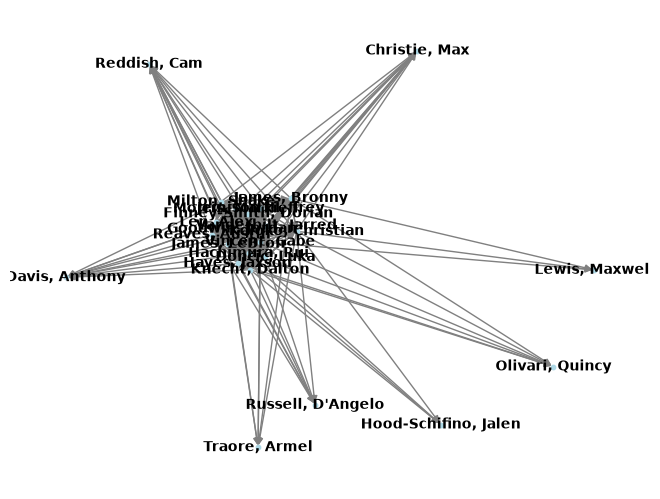

In [78]:
G = nx.DiGraph()

for _, row in pass_df.iterrows():
    G.add_edge(row['player_name'], row['pass_to'], weight=row['proportion'])
nx.draw(G, with_labels=True, node_size=10, node_color='lightblue', font_size=10, font_weight='bold', edge_color='gray')
plt.show()

In [30]:
sorted(nx.pagerank(G, weight="weight").items(), key=lambda x: x[1], reverse=True)

[('Reaves, Austin', 0.1305603852891507),
 ('James, LeBron', 0.1250187917898675),
 ('Dončić, Luka', 0.07111210629609782),
 ('Vincent, Gabe', 0.06119480625053972),
 ('Davis, Anthony', 0.05812383151775665),
 ('Knecht, Dalton', 0.05678952644391624),
 ('Hachimura, Rui', 0.046348568078449635),
 ('Finney-Smith, Dorian', 0.043882680872847614),
 ("Russell, D'Angelo", 0.040650275861633785),
 ('Milton, Shake', 0.0398479153031127),
 ('Goodwin, Jordan', 0.03887507515010965),
 ('Christie, Max', 0.03599358739218786),
 ('Hayes, Jaxson', 0.03539615426575127),
 ('James, Bronny', 0.02718118553431522),
 ('Vanderbilt, Jarred', 0.02534953568975195),
 ('Reddish, Cam', 0.022173048070688983),
 ('Koloko, Christian', 0.022171309557321196),
 ('Morris, Markieff', 0.021567695437189026),
 ('Jemison III, Trey', 0.020980238198801456),
 ('Len, Alex', 0.01904423751226273),
 ('Traore, Armel', 0.014766871574191525),
 ('Olivari, Quincy', 0.014643056469499642),
 ('Lewis, Maxwell', 0.014331549901522087),
 ('Hood-Schifino, Ja

In [31]:
weights = [d["weight"] for _, _, d in G.edges(data=True)]
edgeweights = pd.DataFrame({'links': list(G.edges()), 'weights': weights})
edgeweights.sort_values(by='weights', ascending=False)

,links,weights
224,"(Finney-Smith, Dorian, Reaves, Austin)",0.290
143,"(Hayes, Jaxson, James, LeBron)",0.287
6,"(Vanderbilt, Jarred, Reaves, Austin)",0.286
125,"(Reaves, Austin, James, LeBron)",0.284
256,"(James, LeBron, Reaves, Austin)",0.281
...,...,...
169,"(Hachimura, Rui, Hood-Schifino, Jalen)",0.001
234,"(Finney-Smith, Dorian, Morris, Markieff)",0.001
252,"(James, LeBron, Hood-Schifino, Jalen)",0.000
107,"(Reaves, Austin, James, Bronny)",0.000


From this we can see that Anthony Davis is perseved in his importance to the offense! Gabe Vincent is still important to the network. He is the point guard so this is explainable. Regardless, there is still a natural difference between Austin and Lebron compared to the rest of the pack. The offense runs through these guys. 

In [13]:
from nba_api.stats.endpoints import playercareerstats

In [20]:
t = playercareerstats.PlayerCareerStats(player_id=1631132).get_data_frames()[0]

t[(t['TEAM_ID']==1610612747 )& (t['SEASON_ID']=='2024-25')]

,PLAYER_ID,SEASON_ID,LEAGUE_ID,TEAM_ID,TEAM_ABBREVIATION,PLAYER_AGE,GP,GS,MIN,FGM,...,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PTS
1,1631132,2024-25,00,1610612747,LAL,25.0,37,0,342,40,...,0.714,35,57,92,16,8,16,12,44,90


In [63]:
ids = pass_df['player_id'].unique()

min_played = []

for id in ids:
    print(id)
    player_info = playercareerstats.PlayerCareerStats(player_id=id).get_data_frames()[0]
    if player_info.empty:
        min_played.append(0)
        continue

    player_info_24_lakers = player_info[(player_info['TEAM_ID']==1610612747 )& (player_info['SEASON_ID']=='2024-25')]
    min_played.append(player_info_24_lakers['MIN'].values[0])

pd.DataFrame({'player_id': ids, 'min_played': min_played})

1629020


KeyboardInterrupt: 

for some reason some players have blanks returned in their playercareerstats despite being an active player. we'll manually filter out the names we want in our graph. the cutoff will be set at >5% of the teams total minutes played. the data for this is used from basketball references page for the 24-25 lakers.

in our case 19,730 * .05 = 986.5

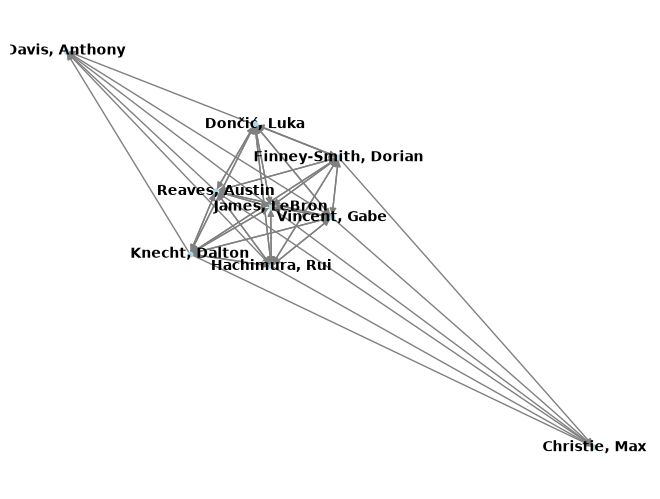

In [77]:
names_incld = ['Reaves, Austin','James, LeBron','Hachimura, Rui','Vincent, Gabe','Knecht, Dalton','Davis, Anthony','Finney-Smith, Dorian','Christie, Max','Hayes, Jaxon','Dončić, Luka']
pass_df_fil = pass_df[(pass_df['player_name'].isin(names_incld)) & (pass_df['pass_to'].isin(names_incld))]

G = nx.DiGraph()

for _, row in pass_df_fil.iterrows():
    G.add_edge(row['player_name'], row['pass_to'], weight=row['proportion'])
nx.draw(G, with_labels=True, node_size=10, node_color='lightblue', font_size=10, font_weight='bold', edge_color='gray')
plt.show()

In [34]:
sorted(nx.degree_centrality(G).items(), key=lambda x: x[1], reverse=True) 

[('Knecht, Dalton', 1.75),
 ('Reaves, Austin', 1.75),
 ('Vincent, Gabe', 1.75),
 ('Hachimura, Rui', 1.75),
 ('Finney-Smith, Dorian', 1.75),
 ('James, LeBron', 1.75),
 ('Dončić, Luka', 1.5),
 ('Christie, Max', 0.75),
 ('Davis, Anthony', 0.75)]

In [35]:
sorted(nx.betweenness_centrality(G, weight='weight').items(), key=lambda x: x[1], reverse=True)

[('Finney-Smith, Dorian', 0.1607142857142857),
 ('Knecht, Dalton', 0.08928571428571427),
 ('Vincent, Gabe', 0.05357142857142857),
 ('Hachimura, Rui', 0.017857142857142856),
 ('Christie, Max', 0.0),
 ('Reaves, Austin', 0.0),
 ('Dončić, Luka', 0.0),
 ('Davis, Anthony', 0.0),
 ('James, LeBron', 0.0)]

In [36]:
sorted(nx.pagerank(G, weight="weight").items(), key=lambda x: x[1], reverse=True)

[('Reaves, Austin', 0.1933104488102944),
 ('James, LeBron', 0.18971760997627937),
 ('Davis, Anthony', 0.11235648397687154),
 ('Dončić, Luka', 0.1056342271407093),
 ('Vincent, Gabe', 0.09241246267449471),
 ('Hachimura, Rui', 0.08753537823141733),
 ('Finney-Smith, Dorian', 0.07852019025473217),
 ('Knecht, Dalton', 0.07272812897841095),
 ('Christie, Max', 0.0677850699567901)]

adding nodes for location where shots are taken to graph

need to convert the raw numbers into proportions respect to the number of attempts they take. 

prop = shots @ loc x / total shot attempts

In [38]:
df

,player_id,restricited_area_att,restricited_area_pct,in_the_paint_att,in_the_paint_pct,mid_range_att,mid_range_pct,left_corner_att,left_corner_pct,right_corner_att,right_corner_pct,above_break3_att,above_break3_pct,backcourt_att,backcourt_pct
0,203458.0,28,0.607,22,0.545,4.0,0.25,2.0,0.5,2.0,0.0,5,0.2,0.0,0.0
1,1642422,10,0.6,2,0.0,0.0,0.0,4.0,0.0,1.0,0.0,2,0.0,0.0,0.0
2,1630559,201,0.692,241,0.465,64.0,0.406,39.0,0.385,30.0,0.567,455,0.369,7.0,0.0
3,1642355,7,0.714,21,0.238,7.0,0.286,4.0,0.25,4.0,0.25,24,0.292,0.0,0.0
4,1629629,30,0.667,14,0.286,3.0,0.333,14.0,0.357,9.0,0.222,24,0.25,0.0,0.0
5,1631132,49,0.714,10,0.3,3.0,0.667,2.0,0.0,0.0,0.0,2,0.0,0.0,0.0
6,1642261,111,0.757,73,0.411,33.0,0.455,57.0,0.439,41.0,0.439,240,0.354,2.0,0.0
7,1627827,90,0.611,28,0.321,3.0,0.667,69.0,0.435,56.0,0.429,188,0.399,1.0,0.0
8,1629216,42,0.643,40,0.425,29.0,0.517,65.0,0.323,47.0,0.489,196,0.332,1.0,0.0
9,1629020,79,0.608,10,0.2,0.0,0.0,9.0,0.222,17.0,0.412,5,0.0,1.0,0.0


In [94]:
total_shots = df.iloc[:,1::2].sum(axis=1)
#converting shot counts to proportions of total shots for each player

prop_shots = df.iloc[:,1::2].div(total_shots, axis=0)

#lets also get the proportions of makes for each player
#getting the number of makes at each location
makes_matrix = df.iloc[:, 1::2].mul(df.iloc[:, 2::2].to_numpy())
total_makes = makes_matrix.sum(axis=1)
prop_makes = makes_matrix.div(total_makes, axis=0)

In [55]:
prop_shots['player_id'] = df['player_id']
prop_shots = prop_shots.iloc[:,[7,0,1,2,3,4,5,6]]
prop_shots

,player_id,restricited_area_att,in_the_paint_att,mid_range_att,left_corner_att,right_corner_att,above_break3_att,backcourt_att
0,203458.0,0.444444,0.349206,0.063492,0.031746,0.031746,0.079365,0.0
1,1642422,0.526316,0.105263,0.0,0.210526,0.052632,0.105263,0.0
2,1630559,0.193828,0.232401,0.061716,0.037608,0.02893,0.438766,0.00675
3,1642355,0.104478,0.313433,0.104478,0.059701,0.059701,0.358209,0.0
4,1629629,0.319149,0.148936,0.031915,0.148936,0.095745,0.255319,0.0
5,1631132,0.742424,0.151515,0.045455,0.030303,0.0,0.030303,0.0
6,1642261,0.199282,0.131059,0.059246,0.102334,0.073609,0.43088,0.003591
7,1627827,0.206897,0.064368,0.006897,0.158621,0.128736,0.432184,0.002299
8,1629216,0.1,0.095238,0.069048,0.154762,0.111905,0.466667,0.002381
9,1629020,0.652893,0.082645,0.0,0.07438,0.140496,0.041322,0.008264


In [96]:
laker_to_id_map = pd.DataFrame({'player_id':pass_df['pass_to_id'].unique(), 'player_name': pass_df['pass_to'].unique()})

prop_makes['player_id'] = df['player_id']
prop_makes = pd.merge(prop_makes, laker_to_id_map, on='player_id', how='left')
prop_makes = prop_makes.iloc[:,[7,8,0,1,2,3,4,5,6]]
prop_makes

,player_id,player_name,restricited_area_att,in_the_paint_att,mid_range_att,left_corner_att,right_corner_att,above_break3_att,backcourt_att
0,203458.0,"Len, Alex",0.531357,0.374851,0.031264,0.031264,0.0,0.031264,0.0
1,1642422,"Traore, Armel",1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1630559,"Reaves, Austin",0.29156,0.234907,0.054467,0.031474,0.035656,0.351936,0.0
3,1642355,"James, Bronny",0.237932,0.237932,0.095306,0.047605,0.047605,0.333619,0.0
4,1629629,"Reddish, Cam",0.526454,0.105343,0.026283,0.131495,0.052566,0.157857,0.0
5,1631132,"Koloko, Christian",0.874934,0.075024,0.050041,0.0,0.0,0.0,0.0
6,1642261,"Knecht, Dalton",0.326919,0.116731,0.058418,0.097356,0.070028,0.330549,0.0
7,1627827,"Finney-Smith, Dorian",0.281957,0.046085,0.01026,0.153899,0.123181,0.384618,0.0
8,1629216,"Vincent, Gabe",0.160703,0.101161,0.089218,0.124934,0.136764,0.38722,0.0
9,1629020,"Vanderbilt, Jarred",0.813633,0.033879,0.0,0.033845,0.118643,0.0,0.0


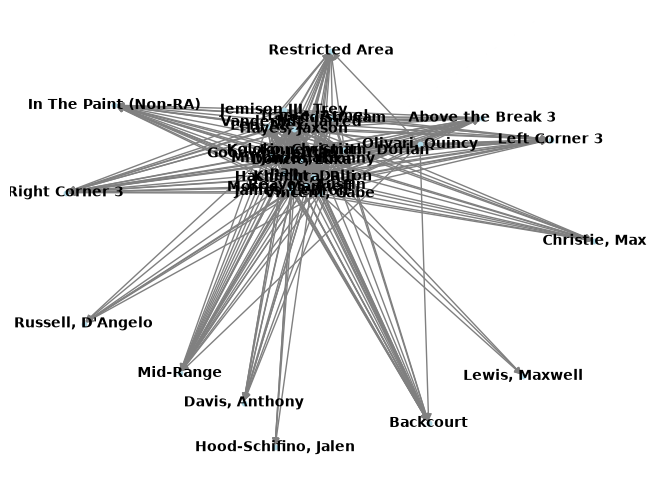

In [104]:
G = nx.DiGraph()

diff_shots = ['Restricted Area', 'In The Paint (Non-RA)', 'Mid-Range', 'Left Corner 3', 'Right Corner 3', 'Above the Break 3', 'Backcourt']

for _, row in pass_df.iterrows():
    G.add_edge(row['player_name'], row['pass_to'], weight=row['proportion'])

for _, row in prop_makes.iterrows():
    for i, shot in enumerate(diff_shots):
        G.add_edge(row['player_name'], shot, weight=row.iloc[i+2])
    
nx.draw(G, with_labels=True, node_size=10, node_color='lightblue', font_size=10, font_weight='bold', edge_color='gray')
plt.show()



In [105]:
sorted(nx.pagerank(G, weight="weight").items(), key=lambda x: x[1], reverse=True)

[('Restricted Area', 0.12294122402058935),
 ('Above the Break 3', 0.08317670426438732),
 ('In The Paint (Non-RA)', 0.05584697787094241),
 ('Reaves, Austin', 0.05036924029345771),
 ('James, LeBron', 0.04763216108830193),
 ('Mid-Range', 0.035129447993479584),
 ('Dončić, Luka', 0.033775179809616585),
 ('Vincent, Gabe', 0.03123072611746784),
 ('Knecht, Dalton', 0.03110755818816743),
 ('Right Corner 3', 0.029464916836555683),
 ('Left Corner 3', 0.029324898469907504),
 ('Milton, Shake', 0.027679807961468274),
 ('Davis, Anthony', 0.027216116347480113),
 ('Goodwin, Jordan', 0.02608982792340359),
 ('Finney-Smith, Dorian', 0.025061955411626813),
 ('Hachimura, Rui', 0.02502050688794847),
 ("Russell, D'Angelo", 0.02419824660370182),
 ('Christie, Max', 0.02310963398173104),
 ('James, Bronny', 0.022775418532894182),
 ('Hayes, Jaxson', 0.022768528476025424),
 ('Vanderbilt, Jarred', 0.020556060241787882),
 ('Morris, Markieff', 0.020307770119604766),
 ('Koloko, Christian', 0.019993677551870623),
 ('Red

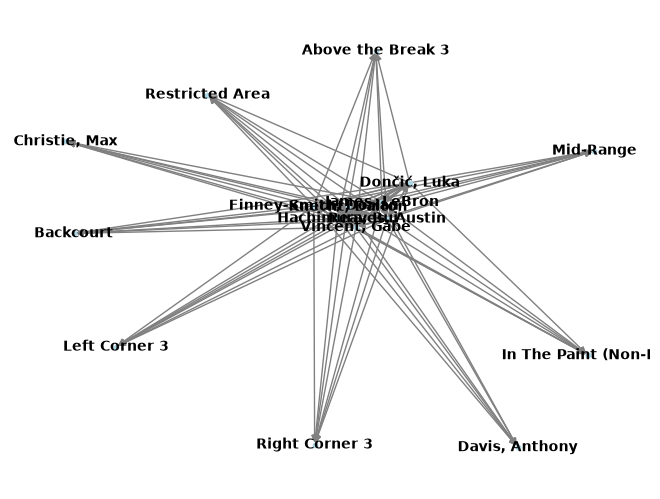

In [106]:
names_incld = ['Reaves, Austin','James, LeBron','Hachimura, Rui','Vincent, Gabe','Knecht, Dalton','Davis, Anthony','Finney-Smith, Dorian','Christie, Max','Hayes, Jaxon','Dončić, Luka']
pass_df_fil = pass_df[(pass_df['player_name'].isin(names_incld)) & (pass_df['pass_to'].isin(names_incld))]

prop_makes_fil = prop_makes[prop_makes['player_name'].isin(names_incld)]

G = nx.DiGraph()

for _, row in pass_df_fil.iterrows():
    G.add_edge(row['player_name'], row['pass_to'], weight=row['proportion'])

for _, row in prop_makes_fil.iterrows():
    for i, shot in enumerate(diff_shots):
        G.add_edge(row['player_name'], shot, weight=row.iloc[i+2])
nx.draw(G, with_labels=True, node_size=10, node_color='lightblue', font_size=10, font_weight='bold', edge_color='gray')
plt.show()

In [107]:
sorted(nx.pagerank(G, weight="weight").items(), key=lambda x: x[1], reverse=True)

[('Restricted Area', 0.10266552625709954),
 ('Above the Break 3', 0.1013562450502496),
 ('Reaves, Austin', 0.07851632815223733),
 ('James, LeBron', 0.0772940797166059),
 ('In The Paint (Non-RA)', 0.07154595627619457),
 ('Dončić, Luka', 0.05732052112719611),
 ('Davis, Anthony', 0.05685780916225106),
 ('Mid-Range', 0.05674541636557999),
 ('Vincent, Gabe', 0.05400513596824697),
 ('Left Corner 3', 0.05308128408639023),
 ('Right Corner 3', 0.0521844418580512),
 ('Hachimura, Rui', 0.05160797574633716),
 ('Finney-Smith, Dorian', 0.05009139935634458),
 ('Knecht, Dalton', 0.04865598412917403),
 ('Christie, Max', 0.047751044290555725),
 ('Backcourt', 0.04032085245748582)]

From this graph we can see there is a clear importance on getting the ball into the paint and shooting threes, with less importance on the mid range shot. The offense does still seem to rotate around Austin Reaves and Lebron James as well.

## Trying on different teams

In [703]:
#ordered list [primary, secondary, tertiary]
team_colors = {'Miami Heat':['#98002e','#f9a01b','#000000'],
               'Los Angeles Lakers':['#552583','#f9a01b','#000000'],
               'Boston Celtics':['#007a33','#ba9653','#963821'],
               'Los Angeles Clippers':['#c8102e','#1d428a','#bec0c2'],
               'Brooklyn Nets':['#002a60','#cd1041','#777d84'],
               'Charlotte Hornets':['#1d1160','#00788c','#a1a1a4'],
               'Chicago Bulls':['#ce1141',"#E8E8E8FF",'#000000'],
               'Atlanta Hawks':['#e03a3e','#c1d32f','#26282a'],
               'Phoenix Suns':['#1d1160','#e56020','#000000'],
               'Dallas Mavericks':['#00538c','#002b5e','#b8c4ca'],
               'Denver Nuggets':['#0e2240','#fec524','#8b2131'],
               'Detroit Pistons':['#c8102e','#1d42ba','#bec0c2'],
               'Golden State Warriors':['#1d428a','#ffc72c','#000000'],
               'Houston Rockets':['#ce1141','#c4ced4','#000000'],
               'Indiana Pacers':['#002d62','#fdbb30','#bec0c2'],
               'Memphis Grizzlies':['#5d76a9','#12173f','#f5b112'],
               'Milwaukee Bucks':['#00471b','#eee1c6','#0077c0'],
               'Minnesota Timberwolves':['#0c2340','#236192','#9ea2a2'],
               'New Orleans Pelicans':['#0c2340','#c8102e','#85714d'],
               'New York Knicks':['#006bb6','#f58426','#bec0c2'],
               'Oklahoma City Thunder':['#007ac1','#ef3b24','#002d62'],
               'Orlando Magic':['#0077c0','#c4ced4','#000000'],
               'Philadelphia 76ers':['#006bb6','#ed174c','#002b5c'],
               'Portland Trail Blazers':['#e03a3e','#E8E8E8FF','#000000'],
               'Sacramento Kings':['#5a2d81','#63727a','#000000'],
               'San Antonio Spurs':['#c4ced4','#E8E8E8FF','#000000'],
               'Toronto Raptors':['#ce1141','#a1a1a4','#000000'],
               'Utah Jazz':['#002b5c','#00471b','#f9a01b'],
               'Cleveland Cavaliers':['#860038','#041e42','#fdbb30'],
               'Washington Wizards':['#002b5c','#e31837','#c4ced4']}



building dictionary with all traded or waived players in the season

In [1127]:
from nba_api.stats.endpoints import PlayerCareerStats

traded_players_min = {}


for player in shots_24[(                     '',         'PLAYER_ID')].unique():
    
    try:
        inf = PlayerCareerStats(player).get_data_frames()[0]

        if not inf.empty:
            team_inf = inf[(inf['SEASON_ID']==yr)&(inf['TEAM_ID']!=0)]
            
            if len(team_inf) > 1:
                total = inf[(inf['SEASON_ID']==yr)&(inf['TEAM_ID']==0)]
                fractions = team_inf.loc[:,'MIN'].values.flatten()/total.loc[:,'MIN'].values
                teamids = team_inf['TEAM_ID'].values
            
                team_frac_inf = dict(zip(teamids, fractions))

                traded_players_min[player] = team_frac_inf
        time.sleep(1)
    except Exception as e:
        print(f'having issues with {player}')
            

having issues with 1642385


In [1131]:
from nba_api.stats.endpoints import TeamPlayerDashboard

def get_team_df(team_id,season,season_type='Regular Season',filtered=False):
    df_values = np.array([])
    
    teamplayerinf = TeamPlayerDashboard(team_id=team_id,season=season,season_type_all_star=season_type).get_data_frames()[1]
    teamplayerinf = teamplayerinf.loc[:,['PLAYER_ID','PLAYER_NAME','MIN']]
    
    if filtered and season_type == 'Regular Season':
        teamplayerinf = teamplayerinf[teamplayerinf['MIN']>=700]
    elif filtered and season_type != 'Regular Season':
        teamplayerinf = teamplayerinf[teamplayerinf['MIN']>=100]
    else:
        teamplayerinf
    
    unique_player_count = 0
    
    #get dictionary of all traded players that year
    #estimate traded players stats respective to their minutes played on the team
    
    traded_shot_df = shots_24[(shots_24[('', 'PLAYER_ID')].isin(traded_players_min.keys()))&(shots_24[('','PLAYER_ID')].isin(teamplayerinf['PLAYER_ID'].tolist()))].copy()

    attempt_cols = [7, 10, 13, 16, 19, 22, 25]

    fractions = traded_shot_df[('', 'PLAYER_ID')].map(lambda pid: traded_players_min[pid][team_id])

    traded_shot_df.iloc[:, attempt_cols] = (traded_shot_df.iloc[:, attempt_cols].mul(fractions, axis=0)).astype(int)
    
    temp = shots_24[shots_24[('', 'PLAYER_ID')].isin(teamplayerinf['PLAYER_ID'])].copy()

    # overwrite traded players with adjusted values
    temp.update(traded_shot_df)
    
    for _, row in temp.iterrows():

        player_id = row.iloc[0]
        
        unique_player_count += 1
        df_values = np.append(df_values, int(player_id))
        df_values = np.append(df_values, row.iloc[[1,7,8,10,11,13,14,16,17,19,20,22,23,25,26]])
        
    
    df = pd.DataFrame(df_values.reshape(unique_player_count, -1), 
                        columns = ['player_id','player_name','restricited_area_att','restricited_area_pct',
                                    'in_the_paint_att','in_the_paint_pct','mid_range_att','mid_range_pct',
                                    'left_corner_att','left_corner_pct','right_corner_att','right_corner_pct',
                                    'above_break3_att','above_break3_pct','backcourt_att','backcourt_pct'])
    return df

In [ ]:
def get_team_pass_df(team_df, team_id, season, season_type='Regular Season'):
    pass_row_inf = []
    
    pulled = {}
    for _, trow in team_df.iterrows():
        while True:
            try:
                if trow['player_id'] in pulled.keys():
                    print(f"Already pulled data for player {trow['player_name']}, skipping...")
                    break
                else:
                    player_info = playerdashptpass.PlayerDashPtPass(team_id=team_id, player_id=int(trow['player_id']), season=season, season_type_all_star=season_type).get_data_frames()[0]
                    #ensure the pass to player is teammate in dataframe
                    player_info = player_info[player_info['PASS_TEAMMATE_PLAYER_ID'].isin(team_df['player_id'])]
                    pulled[trow['player_id']] = True
                    for _, row in player_info.iterrows():
                        pass_row_inf.append({'player_id': row['PLAYER_ID'], 'player_name': row['PLAYER_NAME_LAST_FIRST'], 'pass_to_id': row['PASS_TEAMMATE_PLAYER_ID'], 'pass_to': row['PASS_TO'], 'count': row['PASS'], 'proportion': row['FREQUENCY']})
                    break
            except Exception as e:
                print(f"Error occurred: {trow['player_name']}: {e}")
                print("Retrying after 30 seconds...")
                time.sleep(30)  # Sleep for 30 seconds to avoid rate limiting
                get_team_pass_df(team_df, team_id, season)  # Retry the function
                break
        time.sleep(1)
            
    return pd.DataFrame(pass_row_inf)


In [9]:
team_list = teams.get_teams()
diff_shots = ['Restricted Area', 'In The Paint (Non-RA)', 'Mid-Range', 'Left Corner 3', 'Right Corner 3', 'Above the Break 3', 'Backcourt']


Processing team: Atlanta Hawks
progress 1/30


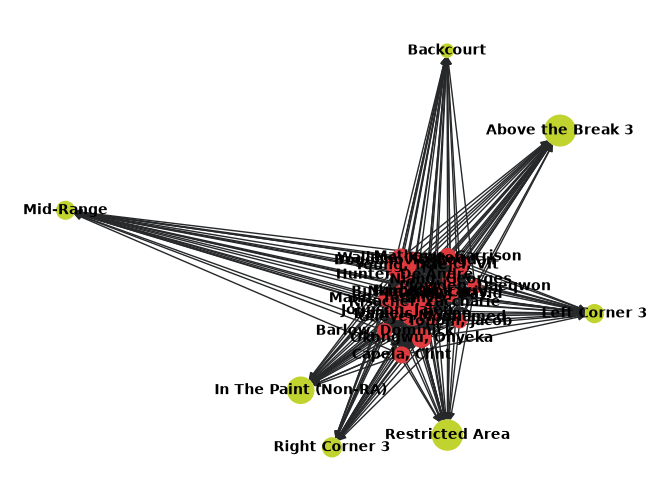

Processing team: Boston Celtics
progress 2/30


In [ ]:
pageranks = {}
count = 0

yr = '2024-25'

shots_24 = leaguedashplayershotlocations.LeagueDashPlayerShotLocations(season=yr, season_type_all_star='Regular Season').get_data_frames()[0]

for team in team_list:
    count += 1
    print(f"Processing team: {team['full_name']}")
    print(f"progress {count}/{len(team_list)}")
    
    team_df = get_team_df(team['id'],yr)
    team_pass_df = get_team_pass_df(team_df, team['id'], yr)
    
    #replacing nans with zero
    team_df.fillna(0, inplace=True)
    
    #getting total shots attempted for each player
    total_shots = team_df.iloc[:,2::2].sum(axis=1)
    
    #saftey to avoid division by zero
    total_shots = total_shots.replace(0, 1)
    
    #converting shot counts to proportions of total shots for each player
    prop_shots = team_df.iloc[:,2::2].div(total_shots, axis=0)

    team_to_id_map = pd.DataFrame({'player_id':team_pass_df['pass_to_id'].unique(), 'player_name': team_pass_df['pass_to'].unique()})

    prop_shots['player_id'] = team_df['player_id']
    prop_shots = pd.merge(prop_shots, team_to_id_map, on='player_id', how='left')
    
    #some merge results in nan
    
    id_of_nan = prop_shots[prop_shots['player_name'].isna()]['player_id'].values
    
    if len(id_of_nan)>0:
        name_of_nan = list(team_df[team_df['player_id'].isin(id_of_nan)]['player_name'])
        prop_shots.fillna(name_of_nan[0],inplace=True)
    
    prop_shots = prop_shots.iloc[:,[7,8,0,1,2,3,4,5,6]]
    G = nx.DiGraph()


    for _, row in team_pass_df.iterrows():
        G.add_edge(row['player_name'], row['pass_to'], weight=row['proportion'])

    for _, row in prop_shots.iterrows():
        for i, shot in enumerate(diff_shots):
            G.add_edge(row['player_name'], shot, weight=row.iloc[i+2])
        
    node_sizes = [list(nx.pagerank(G, weight="weight").items())[i][1]*5000 for i in range(len(list(nx.pagerank(G, weight="weight").items())))]
    node_colors = []
    nodes = list(G.nodes)
    for i in range(len(nodes)):
        if nodes[i] in diff_shots:
            node_colors.append(team_colors[team['full_name']][1])
        else:
            node_colors.append(team_colors[team['full_name']][0])

    nx.draw(G, with_labels=True, node_size=node_sizes, node_color=node_colors, font_size=10, font_weight='bold', edge_color=team_colors[team['full_name']][2])
    plt.show()

    pageranks[team['full_name']] = sorted(nx.pagerank(G, weight="weight").items(), key=lambda x: x[1], reverse=True)
    time.sleep(10)  # Sleep for 10 seconds to avoid rate limiting
        

In [585]:
pageranks_shots_df = []
for team in pageranks.keys():
    #normalizing pageranks to type of shots
    t_shots = sum([pageranks[team][i][1] for i in range(len(pageranks[team])) if pageranks[team][i][0] in diff_shots])
    shot_prop = [pageranks[team][i][1]/t_shots for i in range(len(pageranks[team])) if pageranks[team][i][0] in diff_shots]
    shot_label = [pageranks[team][i][0] for i in range(len(pageranks[team])) if pageranks[team][i][0] in diff_shots]

    pageranks_shots_df.append({'team': team, 'Restricted Area': shot_prop[shot_label.index('Restricted Area')], 'Paint': shot_prop[shot_label.index('In The Paint (Non-RA)')], 'Mid-Range': shot_prop[shot_label.index('Mid-Range')], 'Left Corner': shot_prop[shot_label.index('Left Corner 3')], 'Right Corner': shot_prop[shot_label.index('Right Corner 3')], 'Above Break': shot_prop[shot_label.index('Above the Break 3')], 'Backcourt': shot_prop[shot_label.index('Backcourt')]})

pageranks_shots_df = pd.DataFrame(pageranks_shots_df)

clustering on shot type proportions

Text(0.5, 0, 'Points Sorted')

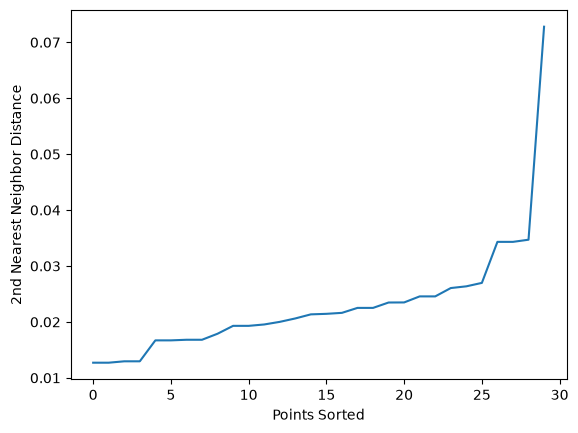

In [586]:
from sklearn.neighbors import NearestNeighbors

X = pageranks_shots_df.iloc[:,1:]

neighbors = NearestNeighbors(n_neighbors=2)
neighbors_fit = neighbors.fit(X)

distances, indices = neighbors_fit.kneighbors(X)

distances = np.sort(distances[:,1])

plt.plot(distances)
plt.ylabel("2nd Nearest Neighbor Distance")
plt.xlabel("Points Sorted")

In [587]:
from sklearn.cluster import DBSCAN, KMeans

#eps determined by the elbow in the above plot
dbscan = DBSCAN(eps=0.03, min_samples=2)
dbscan.fit(pageranks_shots_df.iloc[:,1:])

kmeans = KMeans(n_clusters=4)
kmeans.fit(pageranks_shots_df.iloc[:,1:])


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](4, 7)",

Text(0, 0.5, 'Distance')

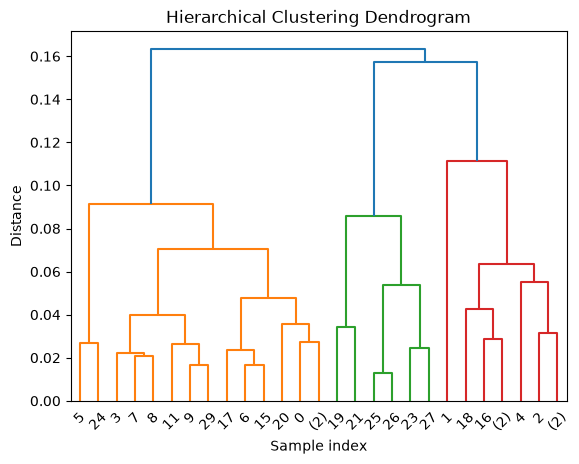

In [588]:
from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(distance_threshold=0,
    n_clusters=None,
    compute_distances=True
)
agg.fit(pageranks_shots_df.iloc[:,1:])

def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]).astype(float)
    dendrogram(linkage_matrix, **kwargs)

plot_dendrogram(agg, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample index")
plt.ylabel("Distance")

In [589]:
clust = AgglomerativeClustering(n_clusters=4)
agg_lab = clust.fit_predict(pageranks_shots_df.iloc[:,1:])

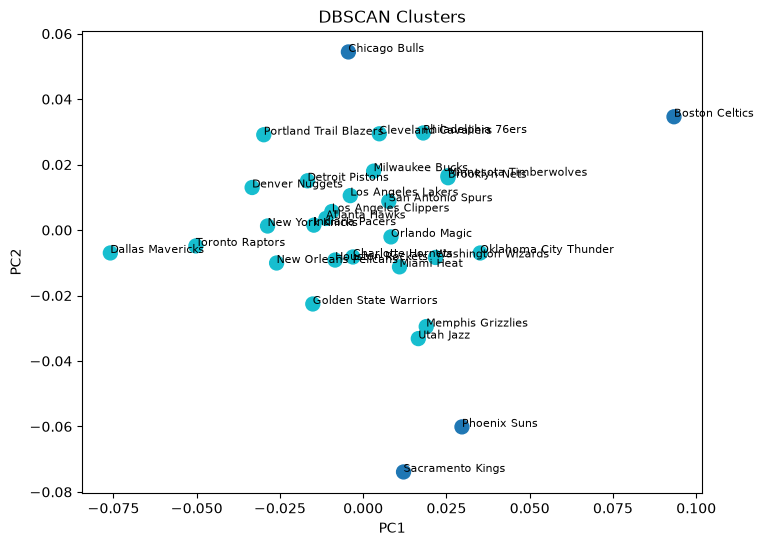

In [590]:
from sklearn.decomposition import PCA

X = pageranks_shots_df.iloc[:,1:]

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=dbscan.labels_,
    cmap='tab10',
    s=100
)

for i, team in enumerate(pageranks_shots_df["team"]):
    plt.text(X_pca[i,0], X_pca[i,1], team, fontsize=8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clusters")
plt.show()



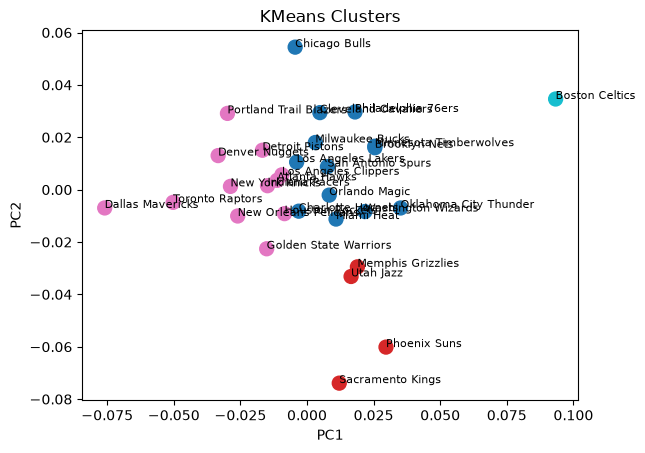

In [591]:
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=kmeans.labels_,
    cmap='tab10',
    s=100
)

for i, team in enumerate(pageranks_shots_df["team"]):
    plt.text(X_pca[i,0], X_pca[i,1], team, fontsize=8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clusters")
plt.show()

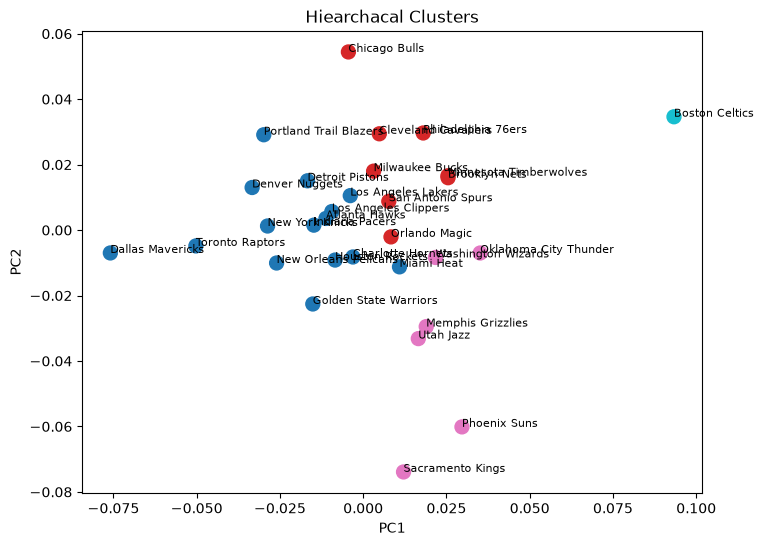

In [592]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=agg_lab,
    cmap='tab10',
    s=100
)

for i, team in enumerate(pageranks_shots_df["team"]):
    plt.text(X_pca[i,0], X_pca[i,1], team, fontsize=8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Hiearchacal Clusters")
plt.show()

In [593]:
centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=pageranks_shots_df.columns[1:]
)

print(centers)

   Restricted Area     Paint  Mid-Range  Left Corner  Right Corner  \
0         0.237164  0.171835   0.099732     0.089456      0.088583   
1         0.194514  0.207768   0.113734     0.098512      0.088851   
2         0.255212  0.182692   0.106245     0.087324      0.087265   
3         0.197516  0.139070   0.092043     0.096264      0.092254   

   Above Break  Backcourt  
0     0.262878   0.050352  
1     0.244128   0.052494  
2     0.230249   0.051013  
3     0.330480   0.052373  


In [594]:
pageranks_shots_df['kmeans_labels'] = kmeans.labels_
pageranks_shots_df[pageranks_shots_df['kmeans_labels']==0]

,team,Restricted Area,Paint,Mid-Range,Left Corner,Right Corner,Above Break,Backcourt,kmeans_labels
2,Cleveland Cavaliers,0.250223,0.158094,0.089989,0.093498,0.095835,0.260325,0.052036,0
4,Chicago Bulls,0.276369,0.156790,0.077170,0.089405,0.081048,0.270666,0.048553,0
10,Los Angeles Lakers,0.244890,0.170494,0.099590,0.095061,0.092083,0.247599,0.050284,0
11,Miami Heat,0.224729,0.192674,0.093256,0.098634,0.086348,0.254024,0.050335,0
12,Milwaukee Bucks,0.243479,0.152314,0.120254,0.085322,0.092058,0.255391,0.051182,0
13,Minnesota Timberwolves,0.229575,0.166561,0.088109,0.094373,0.102319,0.271136,0.047927,0
14,Brooklyn Nets,0.231364,0.174382,0.083476,0.090635,0.095262,0.274871,0.050010,0
16,Orlando Magic,0.226410,0.166667,0.110633,0.096029,0.093466,0.248126,0.058668,0
18,Philadelphia 76ers,0.247533,0.162379,0.106436,0.076426,0.079852,0.281772,0.045602,0
22,San Antonio Spurs,0.238759,0.169585,0.114022,0.084645,0.081556,0.261330,0.050104,0


In [595]:
pageranks_shots_df[pageranks_shots_df['kmeans_labels']==1]

,team,Restricted Area,Paint,Mid-Range,Left Corner,Right Corner,Above Break,Backcourt,kmeans_labels
19,Phoenix Suns,0.178494,0.201589,0.127302,0.103196,0.095098,0.243305,0.051016,1
21,Sacramento Kings,0.185877,0.220417,0.140778,0.089932,0.076946,0.234308,0.051741,1
25,Utah Jazz,0.206013,0.205930,0.091326,0.102594,0.095815,0.246606,0.051716,1
26,Memphis Grizzlies,0.207672,0.203134,0.095528,0.098325,0.087545,0.252294,0.055502,1


In [596]:
pageranks_shots_df[pageranks_shots_df['kmeans_labels']==2]

,team,Restricted Area,Paint,Mid-Range,Left Corner,Right Corner,Above Break,Backcourt,kmeans_labels
0,Atlanta Hawks,0.244893,0.183228,0.087959,0.091534,0.100514,0.238742,0.053130,2
3,New Orleans Pelicans,0.250150,0.196945,0.105294,0.086084,0.085181,0.229897,0.046449,2
5,Dallas Mavericks,0.281782,0.195939,0.110311,0.085306,0.084689,0.190291,0.051681,2
6,Denver Nuggets,0.265366,0.168131,0.113903,0.086742,0.084489,0.228134,0.053235,2
7,Golden State Warriors,0.232316,0.195044,0.108750,0.093411,0.086912,0.228008,0.055559,2
8,Houston Rockets,0.237984,0.187471,0.112282,0.083334,0.086295,0.242035,0.050598,2
9,Los Angeles Clippers,0.249251,0.188724,0.090973,0.087370,0.082883,0.248363,0.052437,2
15,New York Knicks,0.253367,0.171018,0.115724,0.092181,0.092947,0.223418,0.051345,2
17,Indiana Pacers,0.246883,0.169688,0.123491,0.089340,0.085862,0.238106,0.046629,2
20,Portland Trail Blazers,0.275332,0.171586,0.091647,0.083373,0.087113,0.240068,0.050880,2


In [597]:
pageranks_shots_df[pageranks_shots_df['kmeans_labels']==3]

,team,Restricted Area,Paint,Mid-Range,Left Corner,Right Corner,Above Break,Backcourt,kmeans_labels
1,Boston Celtics,0.197516,0.13907,0.092043,0.096264,0.092254,0.33048,0.052373,3


While there isn't a significant difference between each type of offensive strategies there are some general groupings. Breaking down each grouping:

Three and Lays
- Group 0: Three and paint, no midrange
- Group 3: Group 0 but with even more emphasis on the three

Balanced
- Group 1: Balanced approach, but less emphasis on rim shots
- Group 2: Balanced with emphasis on restricted area shots

Pulling in player demographic info as that can add more granularity to who they are running the offense through. PG, C? Their star? etc.

In [598]:
import re 

pageranks_players_df = []

#first converting the pageranks for individual players to a df
for team in pageranks.keys():
    #normalizing the player pagerank to its respective team
    total_rank = np.sum([pageranks[team][i][1] for i in range(len(pageranks[team])) if pageranks[team][i][0] not in diff_shots])
    player_pgranks = [pageranks[team][i][1]/total_rank for i in range(len(pageranks[team])) if pageranks[team][i][0] not in diff_shots]
    player_last_first = [pageranks[team][i][0] for i in range(len(pageranks[team])) if pageranks[team][i][0] not in diff_shots]

    i = 0 
    for player in player_last_first:
        if isinstance(player_last_first[i],float) == True:
            continue
        else:
            last_first = re.split(r',',player)
            try:
                name = last_first[1].strip()+' '+last_first[0]
                player_id = players.find_players_by_full_name(name)[0]['id']
            except:
                print(f"couldn't find id for {name}")
                print('trying other name')
                red_last = re.split(r' ',last_first[0])
                
                name = last_first[1].strip()+' '+red_last[0].strip()
                player_id = players.find_players_by_full_name(name)[0]['id']
            pageranks_players_df.append({'player_id': player_id, 'player_name': name,'team': team, 'pagerank': player_pgranks[i]})
        time.sleep(1)
        i += 1

pageranks_players_df = pd.DataFrame(pageranks_players_df)

couldn't find id for Brandon Boston Jr.
trying other name
couldn't find id for Bobby Portis Jr.
trying other name


In [599]:
pageranks_players_df

,player_id,player_name,team,pagerank
0,1629027,Trae Young,Atlanta Hawks,0.120338
1,1630700,Dyson Daniels,Atlanta Hawks,0.078847
2,1630249,Vít Krejčí,Atlanta Hawks,0.056420
3,1630168,Onyeka Okongwu,Atlanta Hawks,0.055768
4,1630811,Keaton Wallace,Atlanta Hawks,0.055460
...,...,...,...,...
651,1631301,Jaylen Sims,Charlotte Hornets,0.025949
652,1630585,Marcus Garrett,Charlotte Hornets,0.025753
653,1630201,Malachi Flynn,Charlotte Hornets,0.025034
654,1631197,Jared Rhoden,Charlotte Hornets,0.023864


In [600]:
from nba_api.stats.endpoints import leaguedashplayerstats

avdstats = leaguedashplayerstats.LeagueDashPlayerStats(season='2024-25',measure_type_detailed_defense="Advanced").get_data_frames()[0]

avdstats['TOTAL_MIN'] = avdstats['GP']*avdstats['MIN']

#columns of interest: USG_PCT, PIE, TS_PCT
avdstats_fil = avdstats.loc[:,['PLAYER_ID','PLAYER_NAME','TEAM_ID','TOTAL_MIN','USG_PCT','PIE','AST_PCT','TS_PCT','E_OFF_RATING','E_NET_RATING']]

Merging pie on pageranks df

In [828]:
pageranks_players = pd.merge(pageranks_players_df, avdstats_fil.loc[:,['PLAYER_ID','TOTAL_MIN','PIE','E_OFF_RATING','USG_PCT']],left_on = 'player_id', right_on = 'PLAYER_ID', how = 'left')
pageranks_players = pageranks_players.drop('PLAYER_ID', axis = 1)

#adjusting pie by their number of minutes. if its enough samples 1000 total min use that otherwise scale it down

confidence = [min(pageranks_players['TOTAL_MIN'][i] / 1000, 1) for i in range(len(pageranks_players['TOTAL_MIN']))]

adj_pie = pageranks_players['PIE'] * confidence

pageranks_players['ADJ_PIE'] = adj_pie

#filtering out nan
pageranks_players = pageranks_players[~pageranks_players['ADJ_PIE'].isna()]


In [829]:
pageranks_players.loc[:,['pagerank','PIE','ADJ_PIE','E_OFF_RATING','USG_PCT']].corr(method='pearson')

,pagerank,PIE,ADJ_PIE,E_OFF_RATING,USG_PCT
pagerank,1.000000,0.342081,0.626396,0.279844,0.420887
PIE,0.342081,1.000000,0.621728,0.440785,0.497387
ADJ_PIE,0.626396,0.621728,1.000000,0.373783,0.495685
E_OFF_RATING,0.279844,0.440785,0.373783,1.000000,0.095449
USG_PCT,0.420887,0.497387,0.495685,0.095449,1.000000


In [830]:
pie_shares = []

for team in pageranks_players['team'].unique():
    t_pie = np.sum(pageranks_players[pageranks_players['team']==team]['ADJ_PIE'])
    pie_shares.extend(pageranks_players[pageranks_players['team']==team]['ADJ_PIE']/t_pie)
    
pageranks_players['pie_shares'] = pie_shares
pageranks_players

,player_id,player_name,team,pagerank,TOTAL_MIN,PIE,E_OFF_RATING,USG_PCT,ADJ_PIE,pie_shares
0,1629027,Trae Young,Atlanta Hawks,0.120338,2736.0,0.129,114.2,0.285,0.129000,0.088726
1,1630700,Dyson Daniels,Atlanta Hawks,0.078847,2568.8,0.099,112.3,0.178,0.099000,0.068092
2,1630249,Vít Krejčí,Atlanta Hawks,0.056420,1151.4,0.086,109.4,0.131,0.086000,0.059151
3,1630168,Onyeka Okongwu,Atlanta Hawks,0.055768,2064.6,0.122,113.8,0.169,0.122000,0.083912
4,1630811,Keaton Wallace,Atlanta Hawks,0.055460,502.2,0.074,107.9,0.164,0.037163,0.025561
...,...,...,...,...,...,...,...,...,...,...
651,1631301,Jaylen Sims,Charlotte Hornets,0.025949,111.6,0.057,100.3,0.159,0.006361,0.003624
652,1630585,Marcus Garrett,Charlotte Hornets,0.025753,79.2,0.057,93.5,0.193,0.004514,0.002572
653,1630201,Malachi Flynn,Charlotte Hornets,0.025034,43.6,0.084,113.2,0.196,0.003662,0.002086
654,1631197,Jared Rhoden,Charlotte Hornets,0.023864,226.8,0.106,116.3,0.183,0.024041,0.013695


In [831]:
pageranks_players.loc[:,['pagerank','pie_shares']].corr(method='pearson')

,pagerank,pie_shares
pagerank,1.000000,0.680417
pie_shares,0.680417,1.000000


The high correlation between pagerank and pie_shares and adj_pie shows evidence towards the stars dominating the network on their respective teams!

In [605]:
pageranks_players.sort_values(by='pie_shares', ascending=False)

,player_id,player_name,team,pagerank,TOTAL_MIN,PIE,E_OFF_RATING,USG_PCT,ADJ_PIE,pie_shares
131,203999,Nikola Jokić,Denver Nuggets,0.107231,2569.0,0.206,124.3,0.285,0.206000,0.193444
259,203507,Giannis Antetokounmpo,Milwaukee Bucks,0.075700,2291.4,0.210,117.7,0.346,0.210000,0.149192
329,1626157,Karl-Anthony Towns,New York Knicks,0.063828,2520.0,0.161,117.5,0.265,0.161000,0.146985
501,1628983,Shai Gilgeous-Alexander,Oklahoma City Thunder,0.107329,2599.2,0.199,120.6,0.336,0.199000,0.146017
281,1630162,Anthony Edwards,Minnesota Timberwolves,0.086391,2867.7,0.140,114.7,0.307,0.140000,0.134537
...,...,...,...,...,...,...,...,...,...,...
323,1642385,Cui Cui,Brooklyn Nets,0.026761,10.5,-0.056,84.8,0.296,-0.000588,-0.000391
382,1641803,Tristen Newton,Indiana Pacers,0.025768,16.0,-0.068,87.9,0.185,-0.001088,-0.000817
279,1641857,Liam Robbins,Milwaukee Bucks,0.030127,57.2,-0.025,84.0,0.128,-0.001430,-0.001016
298,1641803,Tristen Newton,Minnesota Timberwolves,0.030150,16.0,-0.068,87.9,0.185,-0.001088,-0.001046


In [832]:
pageranks_players['infl_ratio'] = pageranks_players['pagerank']/pageranks_players['ADJ_PIE']

pageranks_players['diff'] = pageranks_players['pagerank'] - pageranks_players['pie_shares']

pageranks_players[pageranks_players['TOTAL_MIN']>= 600].sort_values(by = 'diff', ascending=False).head(n=30)

,player_id,player_name,team,pagerank,TOTAL_MIN,PIE,E_OFF_RATING,USG_PCT,ADJ_PIE,pie_shares,infl_ratio,diff
542,1641718,Keyonte George,Utah Jazz,0.108499,2110.5,0.093,109.2,0.237,0.093000,0.069769,1.166651,0.038730
543,1642268,Isaiah Collier,Utah Jazz,0.094512,1838.9,0.077,107.4,0.186,0.077000,0.057766,1.227429,0.036746
583,1642267,Bub Carrington,Washington Wizards,0.085575,2460.0,0.071,102.5,0.154,0.071000,0.049586,1.205286,0.035990
0,1629027,Trae Young,Atlanta Hawks,0.120338,2736.0,0.129,114.2,0.285,0.129000,0.088726,0.932850,0.031611
176,1642263,Reed Sheppard,Houston Rockets,0.063144,655.2,0.060,107.5,0.171,0.039312,0.032468,1.606217,0.030676
346,1641710,Anthony Black,Orlando Magic,0.091178,1887.6,0.084,104.9,0.190,0.084000,0.061509,1.085450,0.029669
519,1642347,Jamal Shead,Toronto Raptors,0.076320,1470.0,0.070,106.0,0.179,0.070000,0.046969,1.090289,0.029351
356,1641724,Jett Howard,Orlando Magic,0.051052,702.0,0.045,101.9,0.181,0.031590,0.023132,1.616068,0.027920
214,1629216,Gabe Vincent,Los Angeles Lakers,0.051697,1526.4,0.039,112.0,0.131,0.039000,0.024866,1.325576,0.026831
553,1642262,Cody Williams,Utah Jazz,0.042093,1060.0,0.021,103.0,0.122,0.021000,0.015754,2.004443,0.026339


Using the Difference between the proportion of pie and pageranks respective to their teams these are some "undervalued" players. In that they contribute more to the team offense/are more pivotal to the offensive flow of their team than their individual value might suggest. 

Interesting to see that this list is mostly contained of guards. Makes sense as they are the natural facilitator of the offense

Although there are some catch and shoot players like Maxi Kleber and Vasilije Micic that aren't the primary ball handler yet are still key to the offensive flow. 

In [607]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

X = pageranks_players.loc[:,['pie_shares']]
y = pageranks_players['pagerank'].to_numpy()

reg = LinearRegression()
reg.fit(X,y.reshape(-1,1))

y_pred = reg.predict(X)

# 4. Construct the summary output
summary_dict = {
    "Intercept": reg.intercept_,
    "R-Squared (R2)": r2_score(y, y_pred),
    "Mean Absolute Error (MAE)": mean_absolute_error(y, y_pred),
    "Mean Squared Error (MSE)": mean_squared_error(y, y_pred),
    "Root Mean Squared Error (RMSE)": np.sqrt(mean_squared_error(y, y_pred))
}

# 5. Display Coefficients as a neat Table
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': reg.coef_[0]
})

print("--- MODEL METRICS ---")
for key, value in summary_dict.items():
    print(f"{key}: {value}")

print("\n--- MODEL COEFFICIENTS ---")
print(coef_df.to_string(index=False))

--- MODEL METRICS ---
Intercept: [0.02975348]
R-Squared (R2): 0.46296729608598675
Mean Absolute Error (MAE): 0.008752261915821725
Mean Squared Error (MSE): 0.0001445235393684206
Root Mean Squared Error (RMSE): 0.012021794348948938

--- MODEL COEFFICIENTS ---
   Feature  Coefficient
pie_shares     0.338401


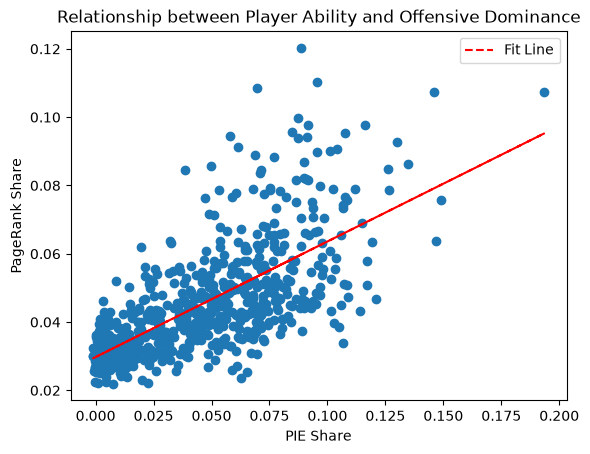

In [608]:


plt.scatter(pageranks_players.loc[:,'pie_shares'],y)

slope = reg.coef_[0]
intercept = reg.intercept_[0]

line_y = slope * pageranks_players.loc[:,'pie_shares'] + intercept
plt.plot(pageranks_players.loc[:,'pie_shares'], line_y, color="red", linestyle="--", label="Fit Line")
plt.xlabel('PIE Share')
plt.ylabel('PageRank Share')
plt.title('Relationship between Player Ability and Offensive Dominance')
plt.legend()
plt.show()

The plot above shows evidence that better players on the team have the offense funneled through them

In [609]:
avdstats_fil

,PLAYER_ID,PLAYER_NAME,TEAM_ID,TOTAL_MIN,USG_PCT,PIE,AST_PCT,TS_PCT,E_OFF_RATING,E_NET_RATING
0,1630639,A.J. Lawson,1610612761,486.2,0.189,0.082,0.093,0.542,109.1,-3.5
1,1631260,AJ Green,1610612749,1657.1,0.123,0.058,0.086,0.621,113.5,6.6
2,1642358,AJ Johnson,1610612764,638.0,0.173,0.053,0.178,0.480,103.5,-11.3
3,203932,Aaron Gordon,1610612743,1448.4,0.186,0.104,0.143,0.650,121.3,8.5
4,1628988,Aaron Holiday,1610612745,793.6,0.162,0.082,0.142,0.594,109.6,4.6
...,...,...,...,...,...,...,...,...,...,...
564,203897,Zach LaVine,1610612758,2604.8,0.251,0.115,0.178,0.639,114.4,-0.9
565,1630192,Zeke Nnaji,1610612743,609.9,0.119,0.063,0.051,0.574,107.6,-1.3
566,1630533,Ziaire Williams,1610612751,1543.5,0.179,0.081,0.086,0.550,105.5,-9.3
567,1629627,Zion Williamson,1610612740,858.0,0.325,0.167,0.325,0.600,112.9,-3.0


In [ ]:
from nba_api.stats.endpoints import commonplayerinfo

player_ids = []
positions = []

for player in avdstats_fil['PLAYER_ID']:
    commoninf = commonplayerinfo.CommonPlayerInfo(player_id=player).get_data_frames()[0][['PERSON_ID','POSITION']]
    player_ids.append(commoninf['PERSON_ID'].values[0])
    positions.append(commoninf['POSITION'].values[0])
    time.sleep(1)


In [614]:
avdstats_fil

,PLAYER_ID,PLAYER_NAME,TEAM_ID,E_NET_RATING,TOTAL_MIN,USG_PCT,PIE,AST_PCT,TS_PCT,E_OFF_RATING
0,1630639,A.J. Lawson,1610612761,-3.5,486.2,0.189,0.082,0.093,0.542,109.1
1,1631260,AJ Green,1610612749,6.6,1657.1,0.123,0.058,0.086,0.621,113.5
2,1642358,AJ Johnson,1610612764,-11.3,638.0,0.173,0.053,0.178,0.480,103.5
3,203932,Aaron Gordon,1610612743,8.5,1448.4,0.186,0.104,0.143,0.650,121.3
4,1628988,Aaron Holiday,1610612745,4.6,793.6,0.162,0.082,0.142,0.594,109.6
...,...,...,...,...,...,...,...,...,...,...
564,203897,Zach LaVine,1610612758,-0.9,2604.8,0.251,0.115,0.178,0.639,114.4
565,1630192,Zeke Nnaji,1610612743,-1.3,609.9,0.119,0.063,0.051,0.574,107.6
566,1630533,Ziaire Williams,1610612751,-9.3,1543.5,0.179,0.081,0.086,0.550,105.5
567,1629627,Zion Williamson,1610612740,-3.0,858.0,0.325,0.167,0.325,0.600,112.9


In [616]:
pos_df = pd.DataFrame({'PLAYER_ID':player_ids, 'POS':positions})

avdstats_fil = pd.merge(avdstats_fil, pos_df, on = 'PLAYER_ID', how = 'left')
avdstats_fil = avdstats_fil.iloc[:,[0,1,2,10,9,3,4,5,6,7,8]]

#converting POS to encoded columns
avdstats_encoded = pd.get_dummies(avdstats_fil, columns=['POS'], dtype=int)

Text(0, 0.5, 'Distance')

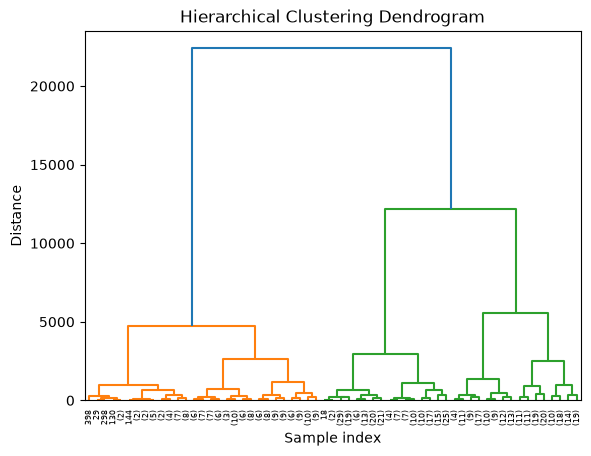

In [618]:
#clustering on player type 

agg = AgglomerativeClustering(distance_threshold=0,
    n_clusters=None,
    compute_distances=True
)
agg.fit(avdstats_encoded.iloc[:,3:])
plot_dendrogram(agg, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample index")
plt.ylabel("Distance")


In [620]:
nclus = 8
clust = AgglomerativeClustering(n_clusters=nclus)
agg_lab = clust.fit_predict(avdstats_encoded.iloc[:,3:])

avdstats_fil['architype_label'] = agg_lab
avdstats_fil

,PLAYER_ID,PLAYER_NAME,TEAM_ID,POS,E_OFF_RATING,E_NET_RATING,TOTAL_MIN,USG_PCT,PIE,AST_PCT,TS_PCT,architype_label
0,1630639,A.J. Lawson,1610612761,Guard,109.1,-3.5,486.2,0.189,0.082,0.093,0.542,2
1,1631260,AJ Green,1610612749,Guard,113.5,6.6,1657.1,0.123,0.058,0.086,0.621,6
2,1642358,AJ Johnson,1610612764,Guard,103.5,-11.3,638.0,0.173,0.053,0.178,0.480,0
3,203932,Aaron Gordon,1610612743,Forward,121.3,8.5,1448.4,0.186,0.104,0.143,0.650,3
4,1628988,Aaron Holiday,1610612745,Guard,109.6,4.6,793.6,0.162,0.082,0.142,0.594,0
...,...,...,...,...,...,...,...,...,...,...,...,...
564,203897,Zach LaVine,1610612758,Guard,114.4,-0.9,2604.8,0.251,0.115,0.178,0.639,4
565,1630192,Zeke Nnaji,1610612743,Forward-Center,107.6,-1.3,609.9,0.119,0.063,0.051,0.574,0
566,1630533,Ziaire Williams,1610612751,Forward,105.5,-9.3,1543.5,0.179,0.081,0.086,0.550,3
567,1629627,Zion Williamson,1610612740,Forward,112.9,-3.0,858.0,0.325,0.167,0.325,0.600,0


In [621]:
avdstats_fil['PIE'].quantile([0.25, 0.5, 0.75])

0.25    0.067
0.50    0.087
0.75    0.110
Name: PIE, dtype: float64

In [623]:
avdstats_fil[(avdstats_fil['architype_label']==0)]

,PLAYER_ID,PLAYER_NAME,TEAM_ID,POS,E_OFF_RATING,E_NET_RATING,TOTAL_MIN,USG_PCT,PIE,AST_PCT,TS_PCT,architype_label
2,1642358,AJ Johnson,1610612764,Guard,103.5,-11.3,638.0,0.173,0.053,0.178,0.480,0
4,1628988,Aaron Holiday,1610612745,Guard,109.6,4.6,793.6,0.162,0.082,0.142,0.594,0
9,1641737,Adem Bona,1610612755,Forward,107.3,-6.8,904.8,0.135,0.093,0.043,0.714,0
10,1642349,Ajay Mitchell,1610612760,Guard,109.3,9.1,597.6,0.159,0.082,0.153,0.587,0
12,202692,Alec Burks,1610612748,Guard,113.1,6.4,862.4,0.160,0.088,0.090,0.608,0
...,...,...,...,...,...,...,...,...,...,...,...,...
525,1630200,Tre Jones,1610612741,Guard,111.7,-1.1,906.2,0.136,0.110,0.289,0.617,0
527,1630570,Trendon Watford,1610612751,Guard-Forward,105.6,-2.7,910.8,0.226,0.101,0.211,0.557,0
549,203995,Vasilije Micic,1610612756,Guard,101.3,-7.1,783.1,0.199,0.061,0.258,0.462,0
565,1630192,Zeke Nnaji,1610612743,Forward-Center,107.6,-1.3,609.9,0.119,0.063,0.051,0.574,0


using shot attempts as weights instead of makes in order to more closely answer the question of how the offense is attempting to score the basket.

In [839]:
#calculating the gini coeffience on the distribution of pagerank among players. 
# High value will hopefully represent how much the offense is centralized around one player

#also adding entropy and effective number of players 

from scipy.stats import entropy

def gini_coef(x):
    x = np.asarray(x, dtype = np.float64)
    
    if np.any(x < 0):
        raise ValueError("Gini coeff requires non negative values")
    x = np.sort(x)
    n = len(x)
    index = np.arange(1, n + 1)

    return (np.sum((2 * index - n - 1)* x)) / (n * np.sum(x))

ginis = []
team_lab = []
entropies = []
effect_num_players = []
for team in pageranks_players['team'].unique():
    #renormalizing after filtering out player with small amount of minutes played
    p = pageranks_players.loc[
    (pageranks_players['team'] == team) &
    (pageranks_players['TOTAL_MIN'] >= 700),
    'pagerank'
    ].to_numpy()
    
    p = p/p.sum()
    
    ginis.append(gini_coef(p))
    entropies.append(entropy(p))
    effect_num_players.append(1/ np.sum(p**2))
    team_lab.append(team)

ginis_df = pd.DataFrame({'team': team_lab, 'gini': ginis, 'entropy': entropies, 'eff_num_players': effect_num_players})

pageranks_shots_df = pd.merge(pageranks_shots_df,ginis_df,on='team',how='left')
pageranks_shots_df

,team,Restricted Area,Paint,Mid-Range,Left Corner,Right Corner,Above Break,Backcourt,gini,entropy,eff_num_players
0,Atlanta Hawks,0.244893,0.183228,0.087959,0.091534,0.100514,0.238742,0.053130,0.180401,2.498583,11.198377
1,Boston Celtics,0.197516,0.139070,0.092043,0.096264,0.092254,0.330480,0.052373,0.184319,2.246971,8.953580
2,Cleveland Cavaliers,0.250223,0.158094,0.089989,0.093498,0.095835,0.260325,0.052036,0.150543,2.528190,12.059306
3,New Orleans Pelicans,0.250150,0.196945,0.105294,0.086084,0.085181,0.229897,0.046449,0.123405,2.540591,12.371705
4,Chicago Bulls,0.276369,0.156790,0.077170,0.089405,0.081048,0.270666,0.048553,0.132068,2.678447,14.101078
5,Dallas Mavericks,0.281782,0.195939,0.110311,0.085306,0.084689,0.190291,0.051681,0.148796,2.530108,12.117044
6,Denver Nuggets,0.265366,0.168131,0.113903,0.086742,0.084489,0.228134,0.053235,0.136400,2.049043,7.529508
7,Golden State Warriors,0.232316,0.195044,0.108750,0.093411,0.086912,0.228008,0.055559,0.109856,2.687426,14.373196
8,Houston Rockets,0.237984,0.187471,0.112282,0.083334,0.086295,0.242035,0.050598,0.148969,2.268585,9.356285
9,Los Angeles Clippers,0.249251,0.188724,0.090973,0.087370,0.082883,0.248363,0.052437,0.128478,2.531117,12.056047


clusterting again but with the player information as well

Text(0, 0.5, 'Distance')

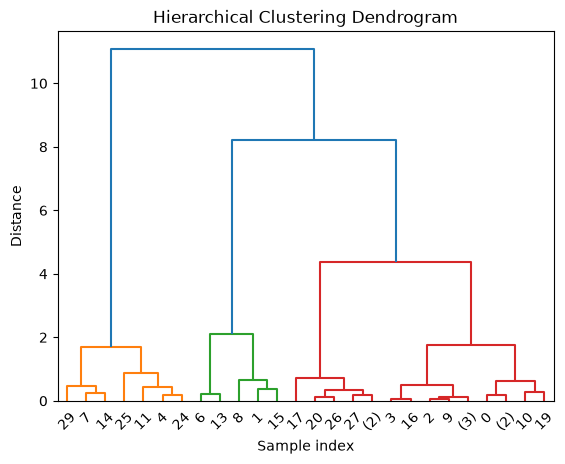

In [840]:
#pageranks_shots_df = pageranks_shots_df.drop(columns='kmeans_labels')

agg = AgglomerativeClustering(distance_threshold=0,
    n_clusters=None,
    compute_distances=True
)
agg.fit(pageranks_shots_df.iloc[:,1:])

plot_dendrogram(agg, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample index")
plt.ylabel("Distance")

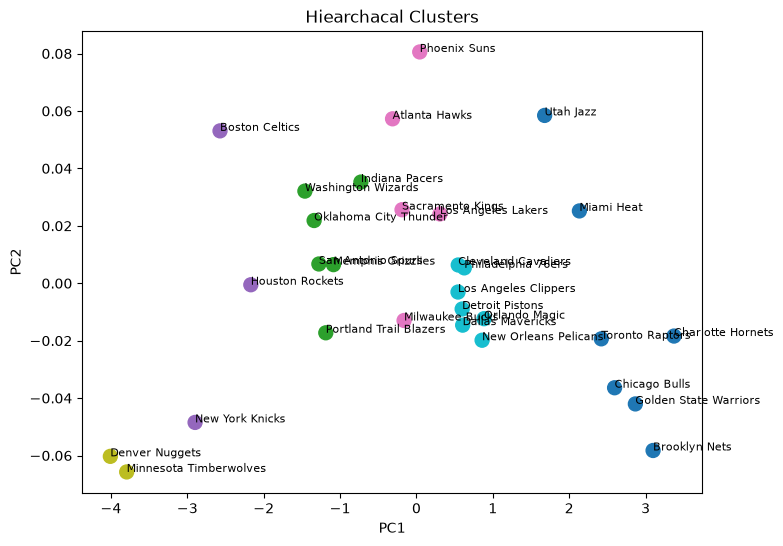

In [841]:
X = pageranks_shots_df.iloc[:,1:]

clust = AgglomerativeClustering(n_clusters=6)
agg_lab = clust.fit_predict(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=agg_lab,
    cmap='tab10',
    s=100
)

for i, team in enumerate(pageranks_shots_df["team"]):
    plt.text(X_pca[i,0], X_pca[i,1], team, fontsize=8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Hiearchacal Clusters")
plt.show()

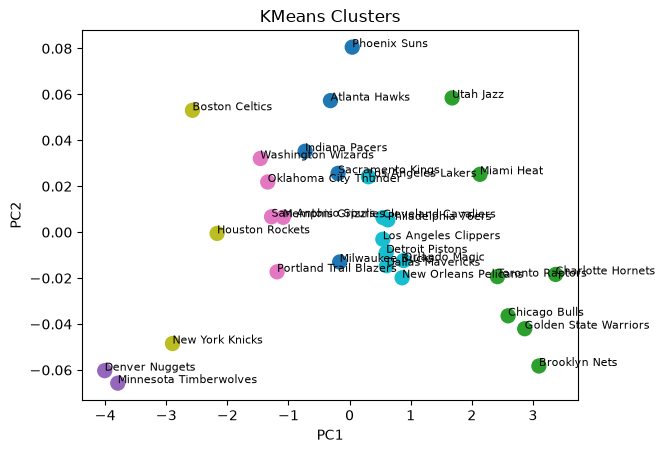

In [842]:
kmeans = KMeans(n_clusters=6)
kmeans.fit(X)

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=kmeans.labels_,
    cmap='tab10',
    s=100
)

for i, team in enumerate(pageranks_shots_df["team"]):
    plt.text(X_pca[i,0], X_pca[i,1], team, fontsize=8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clusters")
plt.show()

In [843]:
centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X.columns
)

print(centers)

   Restricted Area     Paint  Mid-Range  Left Corner  Right Corner  \
0         0.219925  0.185447   0.119957     0.091865      0.090096   
1         0.239494  0.187727   0.094635     0.092707      0.086866   
2         0.247471  0.167346   0.101006     0.090557      0.093404   
3         0.230831  0.182468   0.103070     0.087599      0.085105   
4         0.229622  0.165853   0.106683     0.090593      0.090499   
5         0.250900  0.176298   0.102350     0.087746      0.088005   

   Above Break  Backcourt      gini   entropy  eff_num_players  
0     0.241970   0.050740  0.162724  2.469515        11.244555  
1     0.248010   0.050562  0.139905  2.682475        14.101028  
2     0.249635   0.050581  0.118489  2.056122         7.636308  
3     0.259361   0.051566  0.142280  2.363446        10.249573  
4     0.265311   0.051439  0.149927  2.230358         8.980564  
5     0.243683   0.051018  0.139256  2.531538        12.133832  


Looking at Groups 0-2 the distribution of shots is roughly the same between each shot location. The main/largest difference is seen in the use of effective number of players, with Group 1 having the largest value. This means the offense is more spread out amoungst players in the rotation compared to those in Groups 0 and 2, but especially with Group 2. 

Group 2's entropy and gini scores also support the idea that offense is centered around less players. The lower entropy value denotes less diversity in the player pageranks, with the higher gini denoting greater inequality in the player pageranks. Meaning these teams have more star centered offenses compared to Groups 0 and 1. 

Generally, there is a distinction between balanced teams and centeralized teams. Group 3 is the most extreme case of a balanced team with the highest value in eff_num_players. 

In [844]:
copy = pageranks_shots_df.copy()
copy['H_label'] = agg_lab

hie_clus_inf = []
for lab in range(0,6):
    hie_clus_inf.append({'label': lab,
                         'Restricted Area':copy[copy['H_label']==lab]['Restricted Area'].mean(),
                         'Paint': copy[copy['H_label']==lab]['Paint'].mean(),
                         'Mid Range': copy[copy['H_label']==lab]['Mid-Range'].mean(),
                         'Left': copy[copy['H_label']==lab]['Left Corner'].mean(),
                         'Right': copy[copy['H_label']==lab]['Right Corner'].mean(),
                         'Above Break': copy[copy['H_label']==lab]['Above Break'].mean(),
                         'Backcourt': copy[copy['H_label']==lab]['Backcourt'].mean(),
                         'gini': copy[copy['H_label']==lab]['gini'].mean(),
                         'entropy': copy[copy['H_label']==lab]['entropy'].mean(),
                         'eff_num_players': copy[copy['H_label']==lab]['eff_num_players'].mean()})

pd.DataFrame(hie_clus_inf)

,label,Restricted Area,Paint,Mid Range,Left,Right,Above Break,Backcourt,gini,entropy,eff_num_players
0,0,0.239494,0.187727,0.094635,0.092707,0.086866,0.248010,0.050562,0.139905,2.682475,14.101028
1,1,0.233506,0.180338,0.106473,0.087889,0.085231,0.255819,0.050743,0.148573,2.374513,10.339413
2,2,0.229622,0.165853,0.106683,0.090593,0.090499,0.265311,0.051439,0.149927,2.230358,8.980564
3,3,0.219527,0.185608,0.115177,0.093009,0.091340,0.243869,0.051471,0.159393,2.487257,11.450820
4,4,0.247471,0.167346,0.101006,0.090557,0.093404,0.249635,0.050581,0.118489,2.056122,7.636308
5,5,0.251758,0.177127,0.102744,0.086701,0.087423,0.243124,0.051123,0.135810,2.533391,12.178674


Hieharcal clustering seemed to have found more nauanced differences in shot location proportions, rahther than just differences in player pagranks. 

difference in playoffs?

Processing team: Boston Celtics
progress 1/16


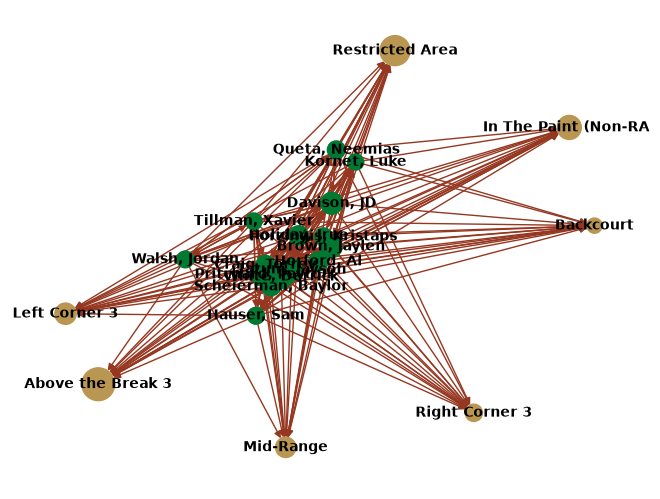

Processing team: Cleveland Cavaliers
progress 2/16


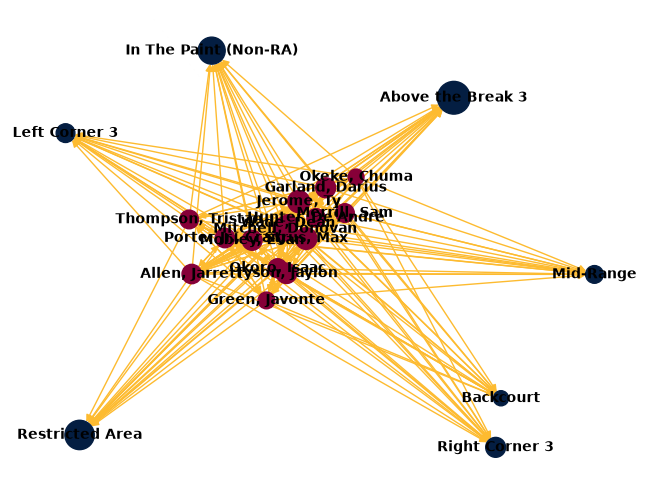

Processing team: Denver Nuggets
progress 3/16


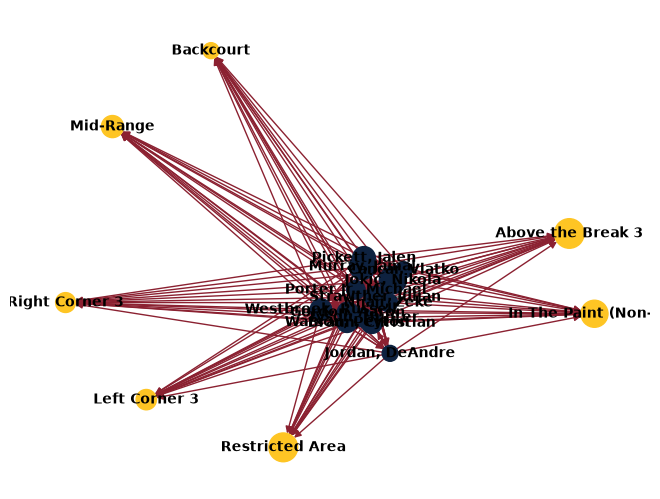

Processing team: Golden State Warriors
progress 4/16


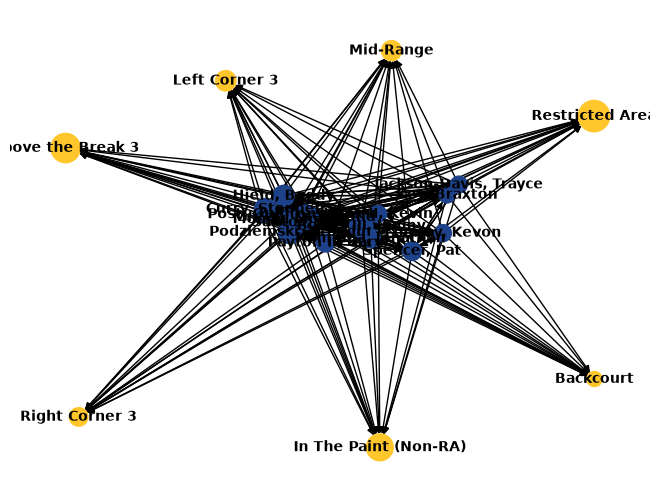

Processing team: Houston Rockets
progress 5/16


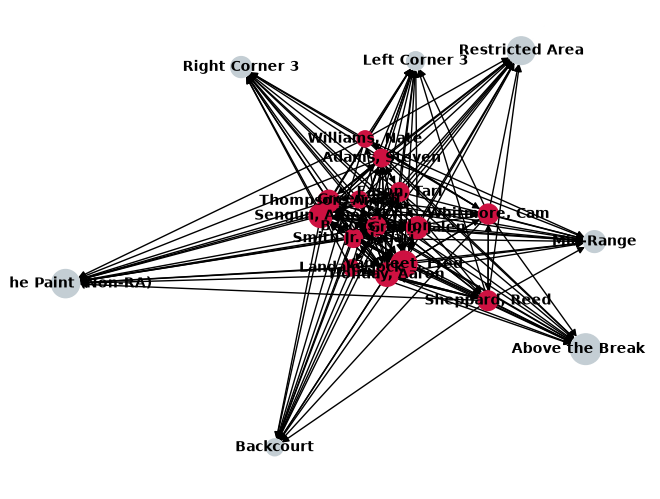

Processing team: Los Angeles Clippers
progress 6/16


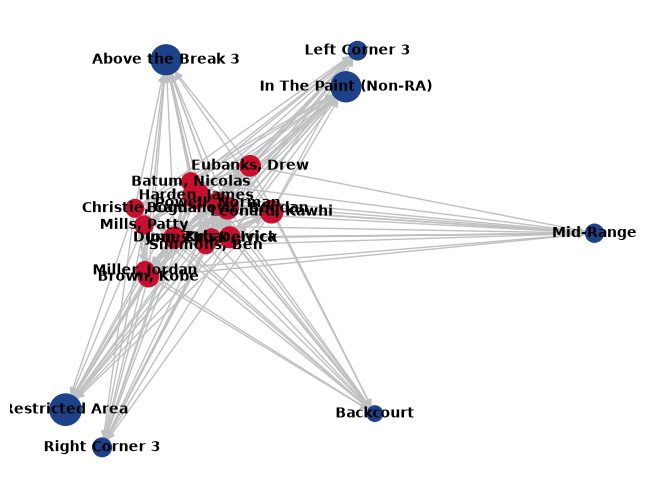

Processing team: Los Angeles Lakers
progress 7/16


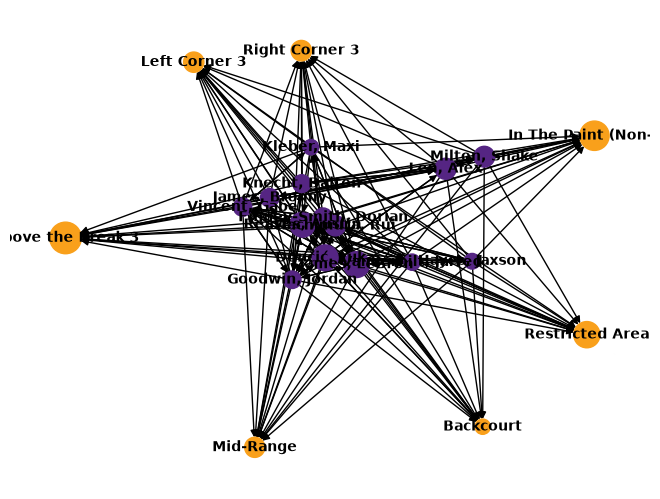

Processing team: Miami Heat
progress 8/16


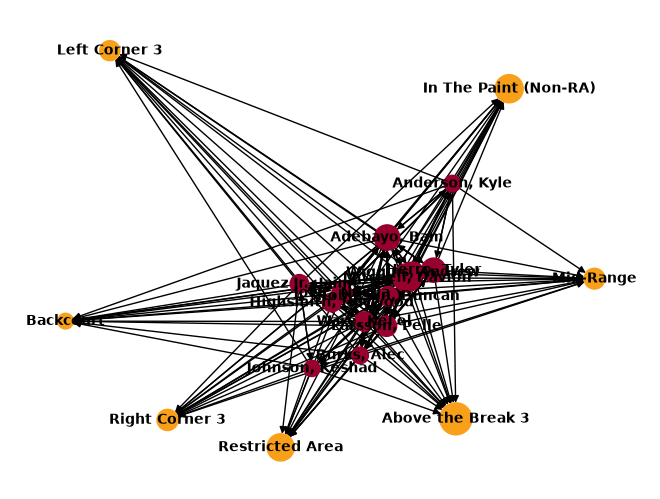

Processing team: Milwaukee Bucks
progress 9/16


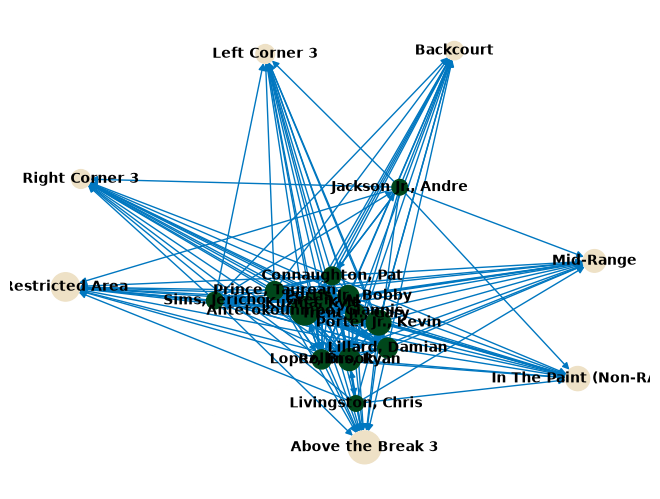

Processing team: Minnesota Timberwolves
progress 10/16


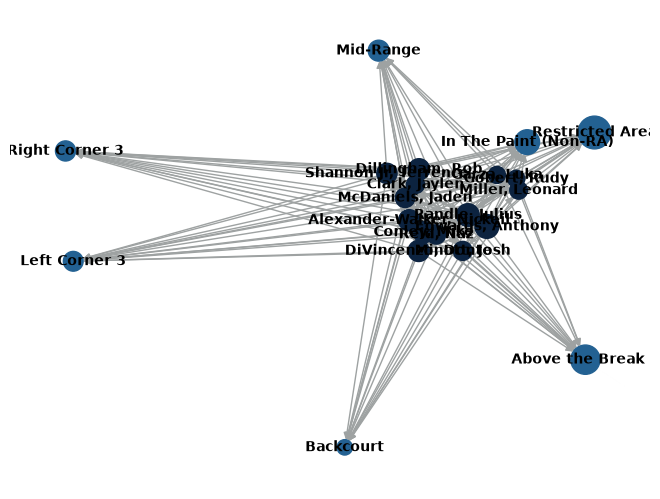

Processing team: New York Knicks
progress 11/16


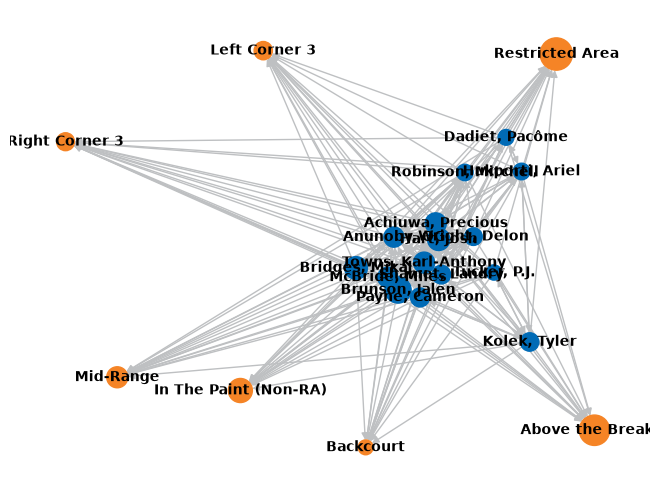

Processing team: Orlando Magic
progress 12/16


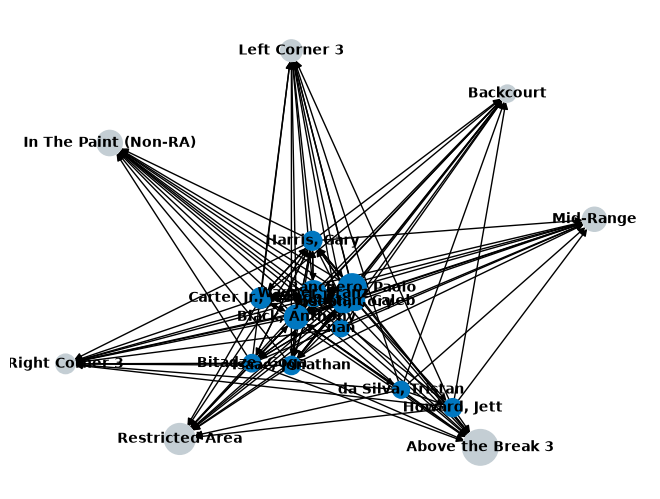

Processing team: Indiana Pacers
progress 13/16


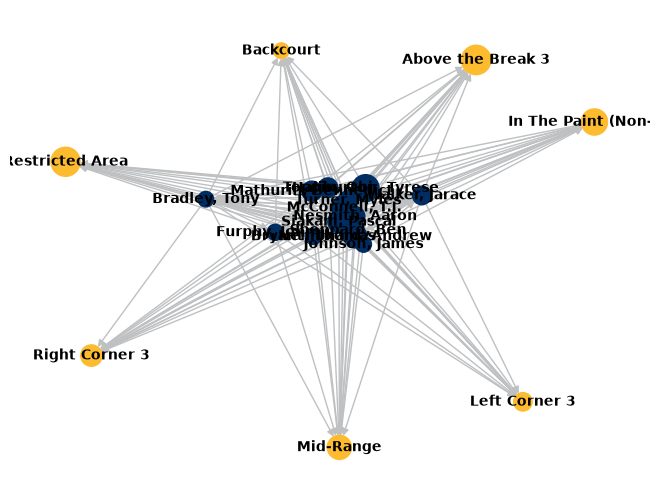

Processing team: Oklahoma City Thunder
progress 14/16


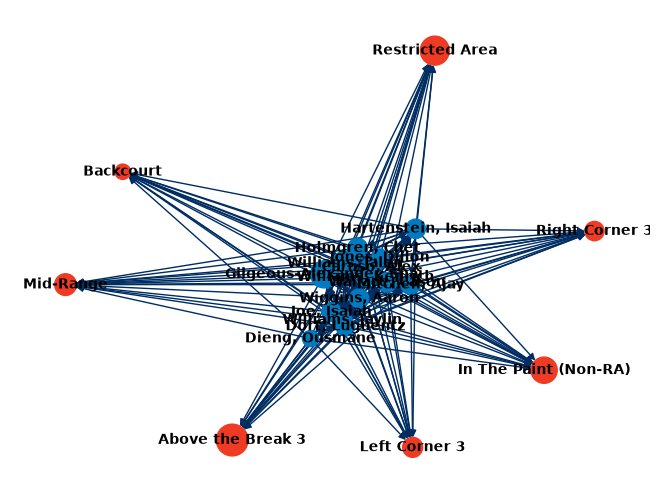

Processing team: Memphis Grizzlies
progress 15/16


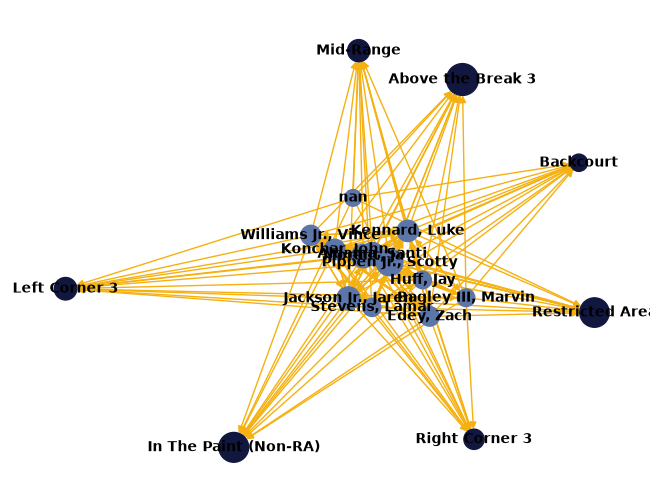

Processing team: Detroit Pistons
progress 16/16


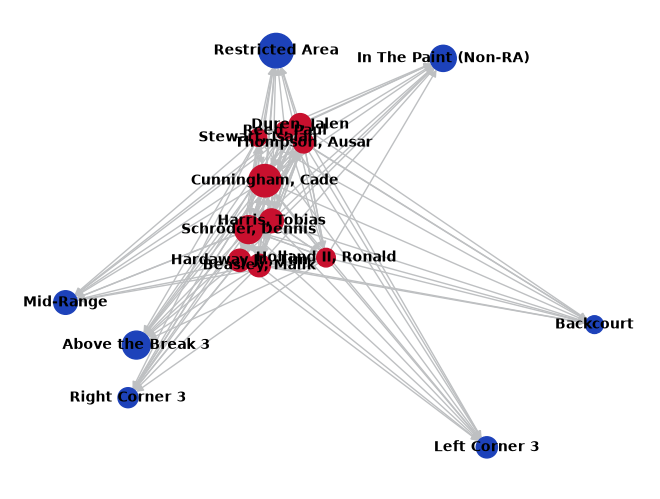

In [ ]:
pageranks_playoffs= {}
count = 0

yr = '2024-25'

shots_24 = leaguedashplayershotlocations.LeagueDashPlayerShotLocations(season=yr, season_type_all_star='Playoffs').get_data_frames()[0]

playoff_team_ids = np.unique(shots_24[[(                     '',           'TEAM_ID')]])
#list containing converted ids to strings for teams in playoffs
playoff_teams = [team_list[ind]['full_name'] for ind in range(len(team_list)) if team_list[ind]['id'] in playoff_team_ids]

indx = 0 

for team in playoff_teams:
    count += 1
    print(f"Processing team: {team}")
    print(f"progress {count}/{len(playoff_teams)}")
    
    team_df = get_team_df(playoff_team_ids[indx],yr,'Playoffs')
    team_pass_df = get_team_pass_df(team_df, playoff_team_ids[indx], yr, 'Playoffs')
    
    #replacing nans with zero
    team_df.fillna(0, inplace=True)
    
    #getting total shots attempted for each player
    total_shots = team_df.iloc[:,2::2].sum(axis=1)
    
    #saftey to avoid division by zero
    total_shots = total_shots.replace(0, 1)
    
    #converting shot counts to proportions of total shots for each player
    prop_shots = team_df.iloc[:,2::2].div(total_shots, axis=0)
    
    team_to_id_map = pd.DataFrame({'player_id':team_pass_df['pass_to_id'].unique(), 'player_name': team_pass_df['pass_to'].unique()})

    prop_shots['player_id'] = team_df['player_id']
    prop_shots = pd.merge(prop_shots, team_to_id_map, on='player_id', how='left')
    prop_shots = prop_shots.iloc[:,[7,8,0,1,2,3,4,5,6]]
    G = nx.DiGraph()


    for _, row in team_pass_df.iterrows():
        G.add_edge(row['player_name'], row['pass_to'], weight=row['proportion'])

    for _, row in prop_shots.iterrows():
        for i, shot in enumerate(diff_shots):
            G.add_edge(row['player_name'], shot, weight=row.iloc[i+2])
        
    node_sizes = [list(nx.pagerank(G, weight="weight").items())[i][1]*5000 for i in range(len(list(nx.pagerank(G, weight="weight").items())))]
    node_colors = []
    nodes = list(G.nodes)
    for i in range(len(nodes)):
        if nodes[i] in diff_shots:
            node_colors.append(team_colors[team][1])
        else:
            node_colors.append(team_colors[team][0])

    nx.draw(G, with_labels=True, node_size=node_sizes, node_color=node_colors, font_size=10, font_weight='bold', edge_color=team_colors[team][2])

    plt.show()

    pageranks_playoffs[team] = sorted(nx.pagerank(G, weight="weight").items(), key=lambda x: x[1], reverse=True)
    indx += 1
    time.sleep(10)  # Sleep for 10 seconds to avoid rate limiting
        

seeing the difference in pageranks compared to their regular season values

In [911]:
pageranks_shots__playoffs_df = []
for team in pageranks_playoffs.keys():
    #normalizing pageranks to type of shots
    t_shots = sum([pageranks_playoffs[team][i][1] for i in range(len(pageranks_playoffs[team])) if pageranks_playoffs[team][i][0] in diff_shots])
    shot_prop = [pageranks_playoffs[team][i][1]/t_shots for i in range(len(pageranks_playoffs[team])) if pageranks_playoffs[team][i][0] in diff_shots]
    shot_label = [pageranks_playoffs[team][i][0] for i in range(len(pageranks_playoffs[team])) if pageranks_playoffs[team][i][0] in diff_shots]

    pageranks_shots__playoffs_df.append({'team': team, 'Restricted Area': shot_prop[shot_label.index('Restricted Area')], 'Paint': shot_prop[shot_label.index('In The Paint (Non-RA)')], 'Mid-Range': shot_prop[shot_label.index('Mid-Range')], 'Left Corner': shot_prop[shot_label.index('Left Corner 3')], 'Right Corner': shot_prop[shot_label.index('Right Corner 3')], 'Above Break': shot_prop[shot_label.index('Above the Break 3')], 'Backcourt': shot_prop[shot_label.index('Backcourt')]})

pageranks_shots__playoffs_df = pd.DataFrame(pageranks_shots__playoffs_df)

In [912]:
pageranks_players_playoffs_df = []

#first converting the pageranks for individual players to a df
for team in pageranks_playoffs.keys():
    #normalizing the player pagerank to its respective team
    total_rank = np.sum([pageranks_playoffs[team][i][1] for i in range(len(pageranks_playoffs[team])) if pageranks_playoffs[team][i][0] not in diff_shots])
    player_pgranks = [pageranks_playoffs[team][i][1]/total_rank for i in range(len(pageranks_playoffs[team])) if pageranks_playoffs[team][i][0] not in diff_shots]
    player_last_first = [pageranks_playoffs[team][i][0] for i in range(len(pageranks_playoffs[team])) if pageranks_playoffs[team][i][0] not in diff_shots]

    i = 0 
    for player in player_last_first:
        if isinstance(player_last_first[i],float) == True:
            continue
        else:
            last_first = re.split(r',',player)
            try:
                name = last_first[1].strip()+' '+last_first[0]
                player_id = players.find_players_by_full_name(name)[0]['id']
            except:
                print(f"couldn't find id for {name}")
                print('trying other name')
                red_last = re.split(r' ',last_first[0])
                
                name = last_first[1].strip()+' '+red_last[0].strip()
                player_id = players.find_players_by_full_name(name)[0]['id']
            pageranks_players_playoffs_df.append({'player_id': player_id, 'player_name': name,'team': team, 'pagerank': player_pgranks[i]})
        time.sleep(1)
        i += 1

pageranks_players_playoffs_df = pd.DataFrame(pageranks_players_playoffs_df)

couldn't find id for Bobby Portis Jr.
trying other name


In [913]:
avdstats_playoffs = leaguedashplayerstats.LeagueDashPlayerStats(season='2024-25',season_type_all_star='Playoffs',measure_type_detailed_defense="Advanced").get_data_frames()[0]

avdstats_playoffs['TOTAL_MIN'] = avdstats_playoffs['GP']*avdstats_playoffs['MIN']

#columns of interest: USG_PCT, PIE, TS_PCT
avdstats_fil_playoffs = avdstats_playoffs.loc[:,['PLAYER_ID','PLAYER_NAME','TEAM_ID','TOTAL_MIN','USG_PCT','PIE','AST_PCT','TS_PCT','E_OFF_RATING','E_NET_RATING']]

pageranks_players_playoffs_df = pd.merge(pageranks_players_playoffs_df, avdstats_fil_playoffs.loc[:,['PLAYER_ID','TOTAL_MIN','PIE','E_OFF_RATING','USG_PCT']],left_on = 'player_id', right_on = 'PLAYER_ID', how = 'left')
pageranks_players_playoffs_df = pageranks_players_playoffs_df.drop('PLAYER_ID', axis = 1)


In [914]:

#adjusting pie by their number of minutes. if its enough samples 1000 total min use that otherwise scale it down

confidence = [min(pageranks_players_playoffs_df['TOTAL_MIN'][i] / 100, 1) for i in range(len(pageranks_players_playoffs_df['TOTAL_MIN']))]

adj_pie = pageranks_players_playoffs_df['PIE'] * confidence

pageranks_players_playoffs_df['ADJ_PIE'] = adj_pie

#filtering out nan
pageranks_players_playoffs_df = pageranks_players_playoffs_df[~pageranks_players_playoffs_df['ADJ_PIE'].isna()]

pie_shares = []

for team in pageranks_players_playoffs_df['team'].unique():
    t_pie = np.sum(pageranks_players_playoffs_df[pageranks_players_playoffs_df['team']==team]['ADJ_PIE'])
    pie_shares.extend(pageranks_players_playoffs_df[pageranks_players_playoffs_df['team']==team]['ADJ_PIE']/t_pie)
    
pageranks_players_playoffs_df['pie_shares'] = pie_shares
pageranks_players_playoffs_df

,player_id,player_name,team,pagerank,TOTAL_MIN,PIE,E_OFF_RATING,USG_PCT,ADJ_PIE,pie_shares
0,1628401,Derrick White,Boston Celtics,0.095734,415.8,0.130,109.4,0.191,0.130000,0.131961
1,1630202,Payton Pritchard,Boston Celtics,0.093761,301.4,0.086,119.5,0.176,0.086000,0.087297
2,1627759,Jaylen Brown,Boston Celtics,0.087701,402.6,0.125,110.5,0.292,0.125000,0.126885
3,1628369,Jayson Tatum,Boston Celtics,0.084620,321.6,0.202,110.9,0.312,0.202000,0.205046
4,1631120,JD Davison,Boston Celtics,0.083299,13.2,0.013,88.4,0.303,0.001716,0.001742
...,...,...,...,...,...,...,...,...,...,...
211,1631105,Jalen Duren,Detroit Pistons,0.092592,203.4,0.133,104.0,0.127,0.133000,0.176447
212,1641709,Ausar Thompson,Detroit Pistons,0.077956,135.0,0.088,107.8,0.213,0.088000,0.116747
213,1641842,Ronald Holland II,Detroit Pistons,0.065169,33.5,-0.039,99.8,0.198,-0.013065,-0.017333
214,1630194,Paul Reed,Detroit Pistons,0.063810,53.0,0.095,103.4,0.123,0.050350,0.066798


In [915]:
ginis = []
team_lab = []
entropies = []
effect_num_players = []
for team in pageranks_shots__playoffs_df['team'].unique():
    #renormalizing after filtering out player with small amount of minutes played
    p = pageranks_players_playoffs_df.loc[
    (pageranks_players_playoffs_df['team'] == team) &
    (pageranks_players_playoffs_df['TOTAL_MIN'] >= 100),
    'pagerank'
    ].to_numpy()
    
    p = p/p.sum()
    
    ginis.append(gini_coef(p))
    entropies.append(entropy(p))
    effect_num_players.append(1/ np.sum(p**2))
    team_lab.append(team)

ginis_playoffs_df = pd.DataFrame({'team': team_lab, 'gini': ginis, 'entropy': entropies, 'eff_num_players': effect_num_players})

pageranks_shots__playoffs_df = pd.merge(pageranks_shots__playoffs_df,ginis_playoffs_df,on='team',how='left')
pageranks_shots__playoffs_df

,team,Restricted Area,Paint,Mid-Range,Left Corner,Right Corner,Above Break,Backcourt,gini,entropy,eff_num_players
0,Boston Celtics,0.228029,0.145918,0.104529,0.114874,0.075910,0.272288,0.058451,0.147051,2.162606,8.424242
1,Cleveland Cavaliers,0.217924,0.184834,0.079369,0.088774,0.100183,0.270937,0.057980,0.110829,2.282654,9.606415
2,Denver Nuggets,0.207992,0.183852,0.122308,0.103500,0.099026,0.219468,0.063854,0.141452,1.911491,6.529890
3,Golden State Warriors,0.248863,0.182575,0.101583,0.105451,0.086576,0.217084,0.057868,0.137308,2.273160,9.442652
4,Houston Rockets,0.190328,0.197344,0.117632,0.082081,0.108964,0.233086,0.070564,0.150463,2.043151,7.435054
5,Los Angeles Clippers,0.243901,0.223208,0.080441,0.083976,0.086290,0.222751,0.059434,0.118595,2.054239,7.598600
6,Los Angeles Lakers,0.171498,0.214509,0.100659,0.102311,0.104336,0.248368,0.058319,0.129773,1.577678,4.714603
7,Miami Heat,0.181075,0.193971,0.105627,0.098396,0.109556,0.251164,0.060212,0.113646,1.364986,3.837035
8,Milwaukee Bucks,0.200054,0.144563,0.127406,0.087322,0.087665,0.269152,0.083837,0.151072,1.750227,5.505132
9,Minnesota Timberwolves,0.267641,0.153002,0.108949,0.097149,0.100720,0.213538,0.059001,0.102785,2.061922,7.734537


In [916]:
diff_reg_v_play = pageranks_shots_df[pageranks_shots_df['team'].isin(playoff_teams)].reset_index(drop=True)-pageranks_shots__playoffs_df.iloc[:,1:]
diff_reg_v_play.drop('team', axis = 1)
diff_reg_v_play['team'] = pageranks_shots__playoffs_df['team']

diff_reg_v_play = diff_reg_v_play.iloc[:,[10,0,1,2,3,4,5,6,7,8,9]]
diff_reg_v_play

,team,Above Break,Backcourt,Left Corner,Mid-Range,Paint,Restricted Area,Right Corner,eff_num_players,entropy,gini
0,Boston Celtics,0.058192,-0.006078,-0.018610,-0.012486,-0.006849,-0.030513,0.016344,0.529339,0.084365,0.037268
1,Cleveland Cavaliers,-0.010612,-0.005944,0.004724,0.010621,-0.026740,0.032299,-0.004348,2.452891,0.245536,0.039714
2,Denver Nuggets,0.008666,-0.010619,-0.016758,-0.008405,-0.015721,0.057374,-0.014538,0.999618,0.137553,-0.005051
3,Golden State Warriors,0.010924,-0.002309,-0.012040,0.007167,0.012469,-0.016547,0.000335,4.930545,0.414266,-0.027452
4,Houston Rockets,0.008949,-0.019966,0.001253,-0.005350,-0.009872,0.047655,-0.022669,1.921231,0.225435,-0.001494
5,Los Angeles Clippers,0.025612,-0.006997,0.003394,0.010532,-0.034484,0.005350,-0.003407,4.457446,0.476878,0.009883
6,Los Angeles Lakers,-0.000769,-0.008035,-0.007251,-0.001070,-0.044015,0.073392,-0.012253,7.105335,0.940884,0.033612
7,Miami Heat,0.002860,-0.009877,0.000238,-0.012370,-0.001297,0.043654,-0.023208,9.802991,1.296566,0.055088
8,Milwaukee Bucks,-0.013761,-0.032655,-0.002000,-0.007152,0.007751,0.043425,0.004392,5.848563,0.708225,-0.030282
9,Minnesota Timberwolves,0.057598,-0.011073,-0.002777,-0.020840,0.013559,-0.038066,0.001599,0.008571,0.001279,-0.002208


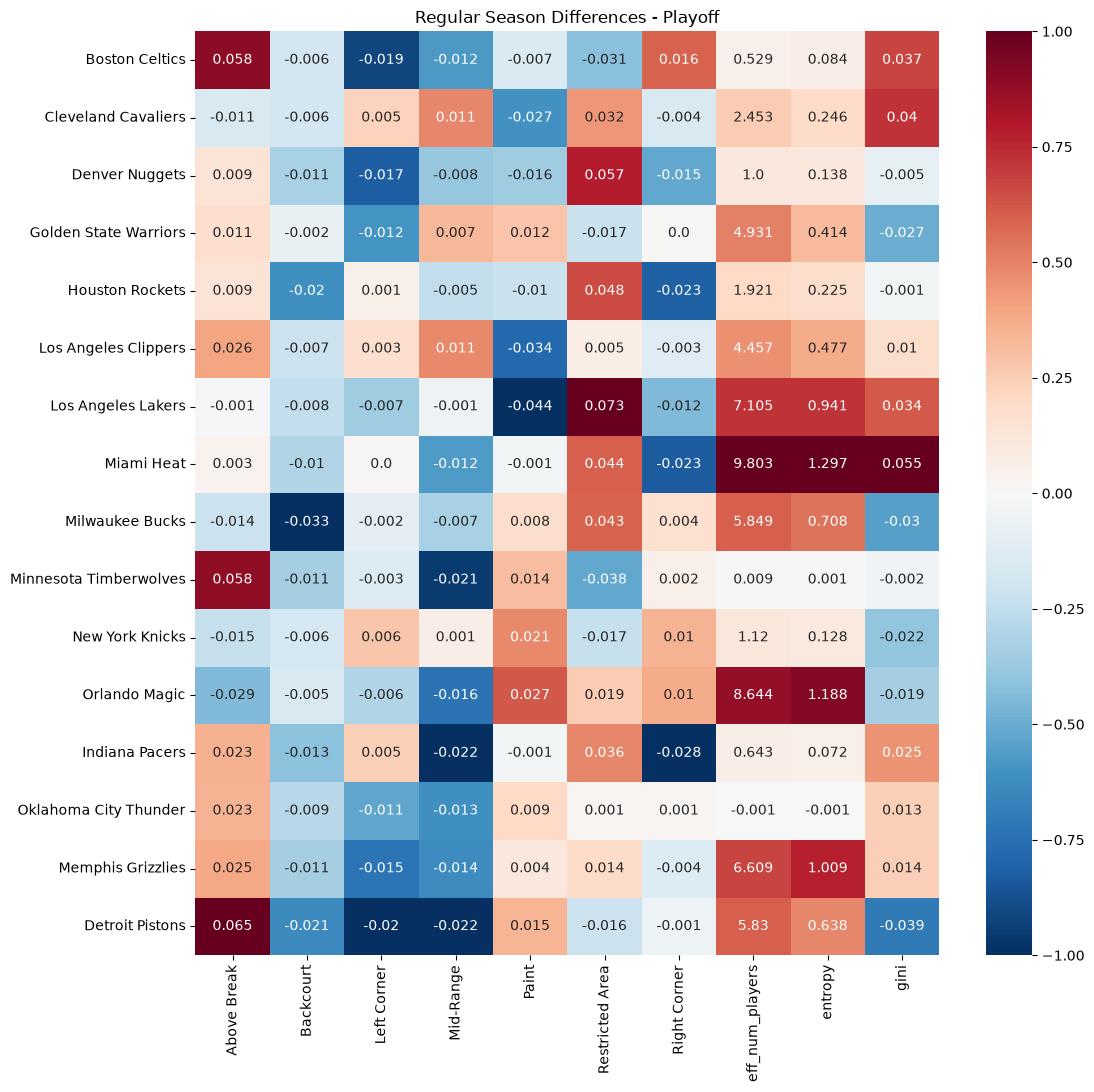

In [917]:
import seaborn as sns

heat = diff_reg_v_play.set_index('team')
heat_plot = heat.div(heat.abs().max())

plt.figure(figsize=(12, 12))

sns.heatmap(
    heat_plot,
    cmap="RdBu_r",
    center=0,
    annot=heat.round(3),   # show original values
    fmt="",
)


plt.title("Regular Season Differences - Playoff")
plt.ylabel("")
plt.show()

This heatmap shows that teams do change there offensive strategies come playoff time! Most noticably is in the effective number of players. Almost entirely across the board teams focus the offense through a smaller pool of players. Another large trend seems to be a reduction in the propotion of shot attempts from above the break 3s. Some teams like the Bucks, Knicks and Magic took more shots at this location during the playoffs. It seems some teams took a more balanced approach come playoff time, while others honed in on speicific areas of the court like the left corner 3, midrange, and paint. 

## Filtered analysis

Same analysis as above but filtering out players with low total minutes played when initially building out the graph. This should result in less noisy pagerank values

In [929]:
avdstats[avdstats['PLAYER_NAME']=='Anthony Davis']

,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,AGE,GP,W,L,W_PCT,...,PACE_RANK,sp_work_PACE_RANK,PIE_RANK,FGM_RANK,FGA_RANK,FGM_PG_RANK,FGA_PG_RANK,FG_PCT_RANK,TEAM_COUNT,TOTAL_MIN
28,203076,Anthony Davis,Anthony,1610612742,DAL,32.0,51,30,21,0.588,...,466,466,6,46,61,9,27,97,2,1703.4


In [954]:
TeamPlayerDashboard(team_id=team_list[10]['id'],season=yr).get_data_frames()[1]

,GROUP_SET,PLAYER_ID,PLAYER_NAME,NICKNAME,GP,W,L,W_PCT,MIN,FGM,...,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,TEAM_COUNT
0,Players,203458,Alex Len,Alex,10,2,8,0.200,122.116667,10,...,6,7,21,20,21,20,8,4,20,1
1,Players,203076,Anthony Davis,Anthony,42,24,18,0.571,1439.483333,400,...,21,17,3,3,9,3,1,4,3,1
2,Players,1642422,Armel Traore,Armel,9,5,4,0.556,66.666667,6,...,4,4,19,21,18,21,8,4,21,1
3,Players,1630559,Austin Reaves,Austin,73,46,27,0.630,2550.091667,477,...,23,23,1,2,2,2,4,3,2,1
4,Players,1642355,Bronny James,Bronny,27,17,10,0.630,181.243333,21,...,8,5,17,17,22,18,8,4,18,1
5,Players,1629629,Cam Reddish,Cam,33,15,18,0.455,589.450000,38,...,8,10,13,15,24,14,8,4,14,1
6,Players,1631132,Christian Koloko,Christian,37,23,14,0.622,341.530000,40,...,11,12,14,16,12,15,8,4,15,1
7,Players,1626156,D'Angelo Russell,D'Angelo,29,16,13,0.552,763.325000,129,...,12,13,9,10,7,11,6,4,11,1
8,Players,1642261,Dalton Knecht,Dalton,78,47,31,0.603,1493.795000,257,...,20,19,8,6,23,6,8,4,6,1
9,Players,1627827,Dorian Finney-Smith,Dorian,43,29,14,0.674,1239.431667,122,...,16,17,15,11,1,10,8,4,10,1


In [956]:
team_df = get_team_df(team_list[10]['id'])
#filtering out players that don't have a large enough sample
teamplayerinf = TeamPlayerDashboard(team_id=team_list[10]['id'],season=yr).get_data_frames()[1]
team_df = pd.merge(team_df,teamplayerinf.loc[:,['PLAYER_ID','MIN']],left_on='player_id',right_on='PLAYER_ID',how='right')
team_df[team_df['MIN']>=700]

,player_id,player_name,restricited_area_att,restricited_area_pct,in_the_paint_att,in_the_paint_pct,mid_range_att,mid_range_pct,left_corner_att,left_corner_pct,right_corner_att,right_corner_pct,above_break3_att,above_break3_pct,backcourt_att,backcourt_pct,PLAYER_ID,MIN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,203076,1439.483333
3,1630559,Austin Reaves,201,0.692,241,0.465,64.0,0.406,39.0,0.385,30.0,0.567,455,0.369,7.0,0.0,1630559,2550.091667
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1626156,763.325000
8,1642261,Dalton Knecht,111,0.757,73,0.411,33.0,0.455,57.0,0.439,41.0,0.439,240,0.354,2.0,0.0,1642261,1493.795000
9,1627827,Dorian Finney-Smith,90,0.611,28,0.321,3.0,0.667,69.0,0.435,56.0,0.429,188,0.399,1.0,0.0,1627827,1239.431667
10,1629216,Gabe Vincent,42,0.643,40,0.425,29.0,0.517,65.0,0.323,47.0,0.489,196,0.332,1.0,0.0,1629216,1527.265000
13,1629637,Jaxson Hayes,180,0.806,38,0.395,2.0,0.5,1.0,0.0,0.0,0.0,2,0.0,0.0,0.0,1629637,1092.683333
15,2544,LeBron James,386,0.744,270,0.444,218.0,0.436,23.0,0.348,14.0,0.357,357,0.381,2.0,0.0,2544,2444.446667
16,1629029,Luka Dončić,158,0.709,229,0.485,157.0,0.389,18.0,0.389,7.0,0.429,454,0.368,2.0,0.0,1629029,984.036667
18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1631108,1154.140000


Processing team: Atlanta Hawks
progress 1/30


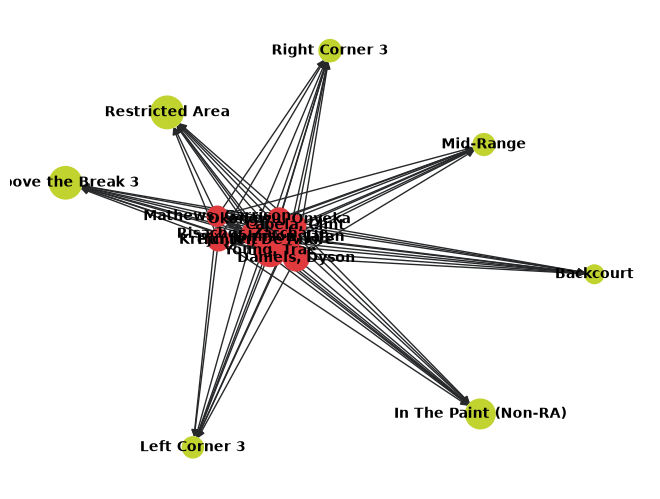

Processing team: Boston Celtics
progress 2/30


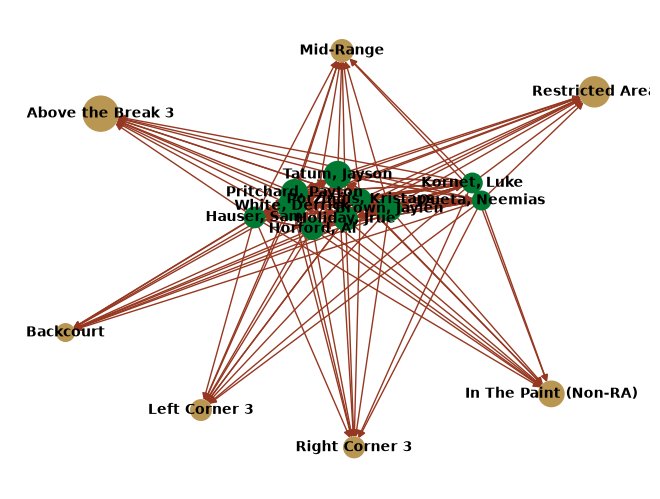

Processing team: Cleveland Cavaliers
progress 3/30


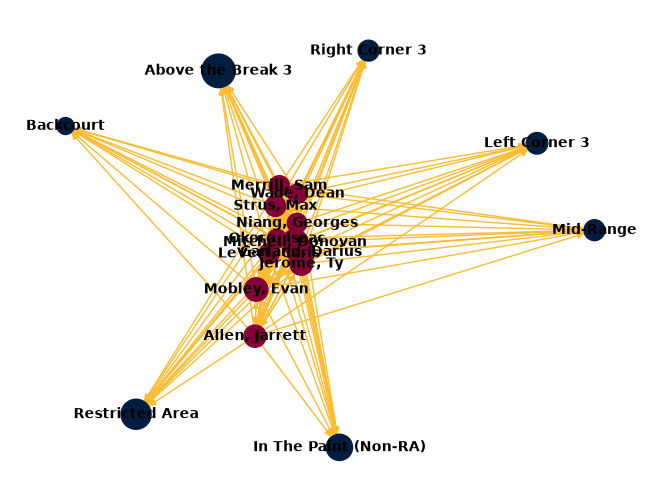

Processing team: New Orleans Pelicans
progress 4/30


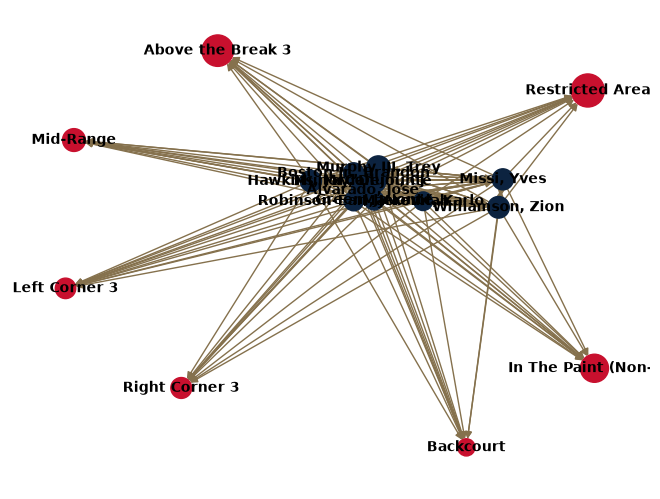

Processing team: Chicago Bulls
progress 5/30


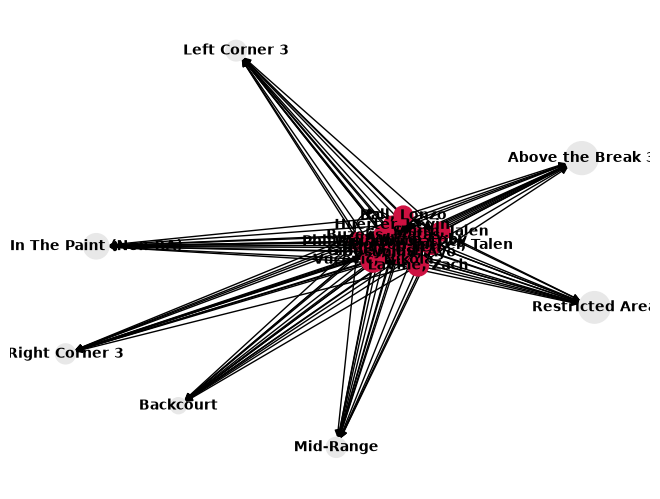

Processing team: Dallas Mavericks
progress 6/30


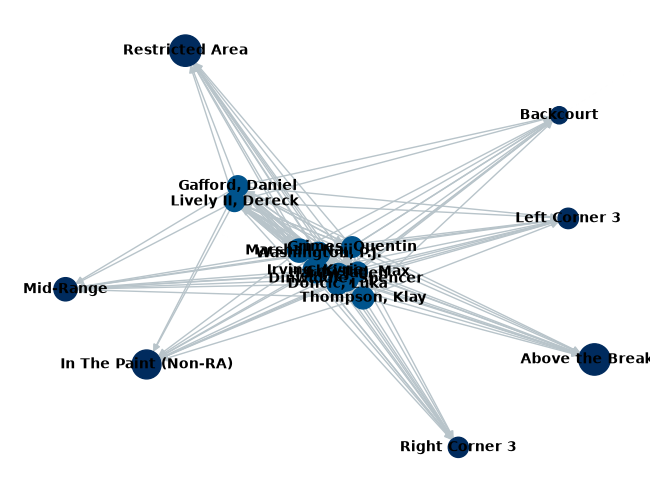

Processing team: Denver Nuggets
progress 7/30


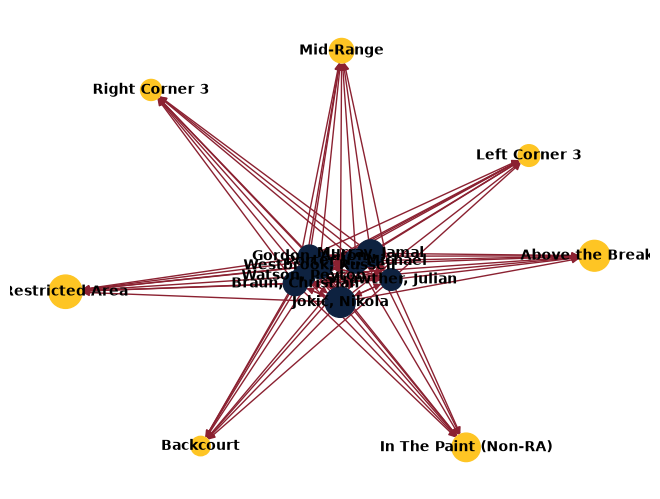

Processing team: Golden State Warriors
progress 8/30


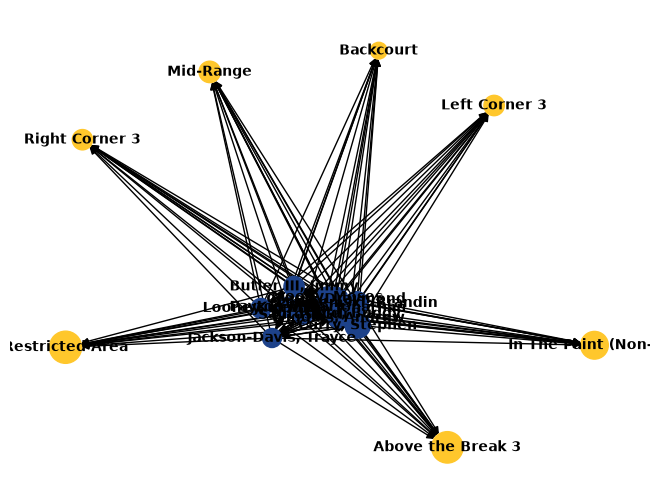

Processing team: Houston Rockets
progress 9/30


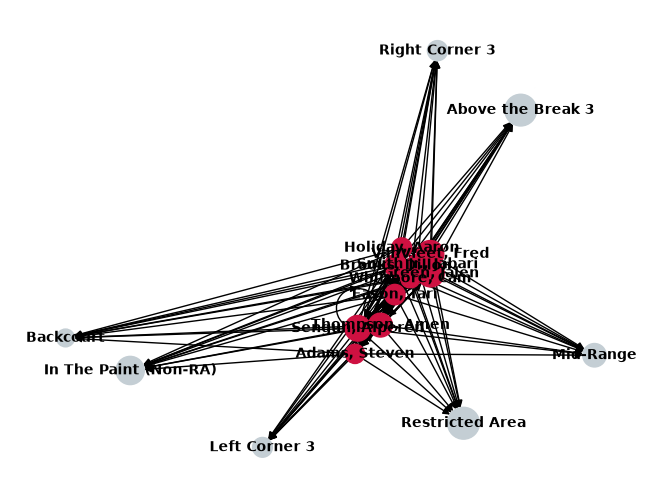

Processing team: Los Angeles Clippers
progress 10/30


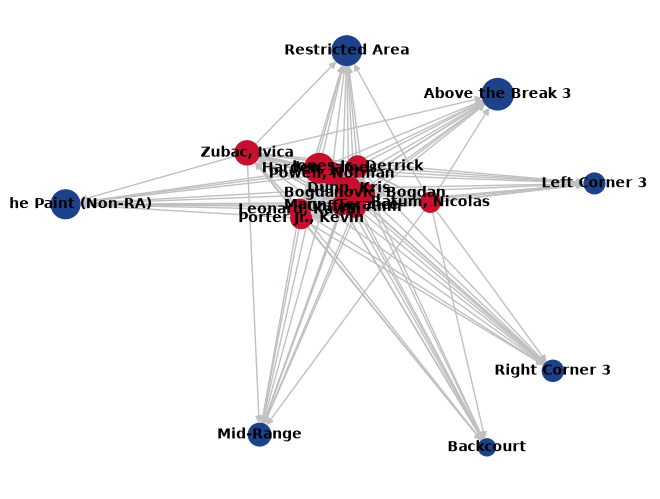

Processing team: Los Angeles Lakers
progress 11/30


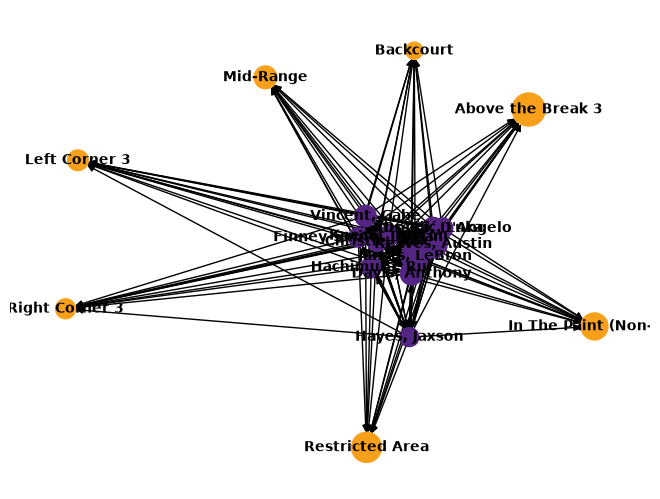

Processing team: Miami Heat
progress 12/30


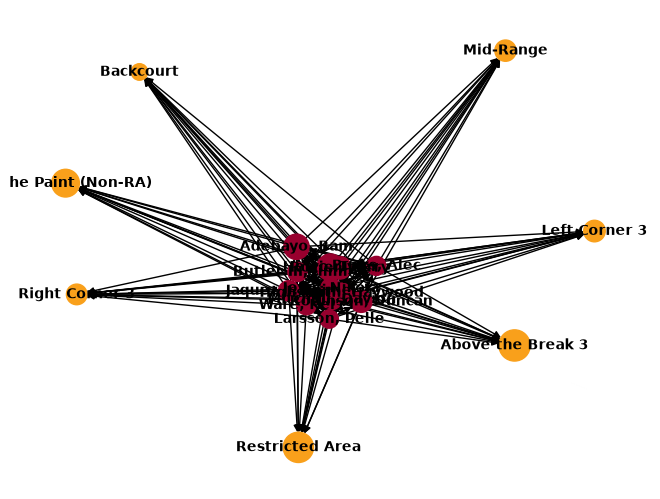

Processing team: Milwaukee Bucks
progress 13/30


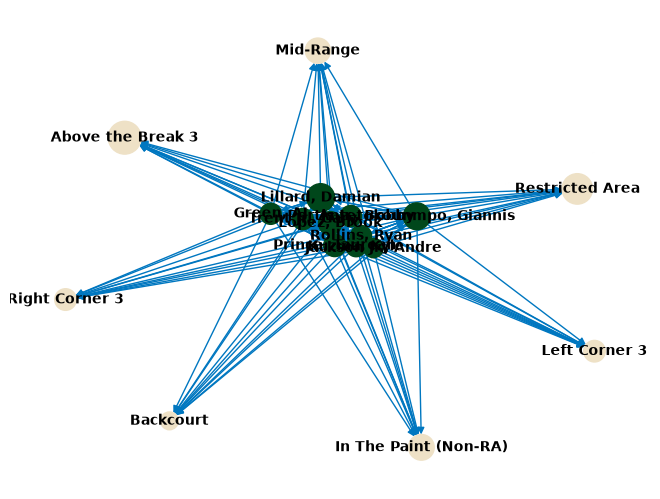

Processing team: Minnesota Timberwolves
progress 14/30


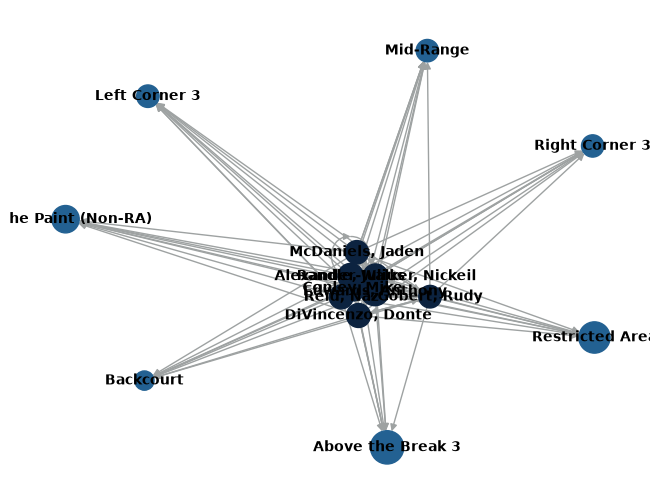

Processing team: Brooklyn Nets
progress 15/30


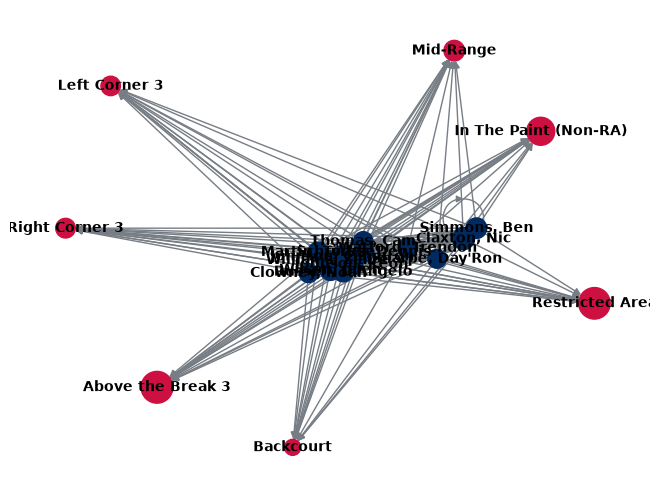

Processing team: New York Knicks
progress 16/30


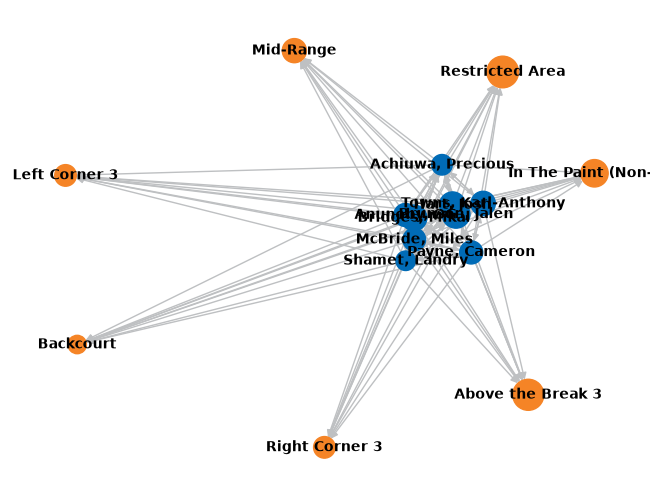

Processing team: Orlando Magic
progress 17/30


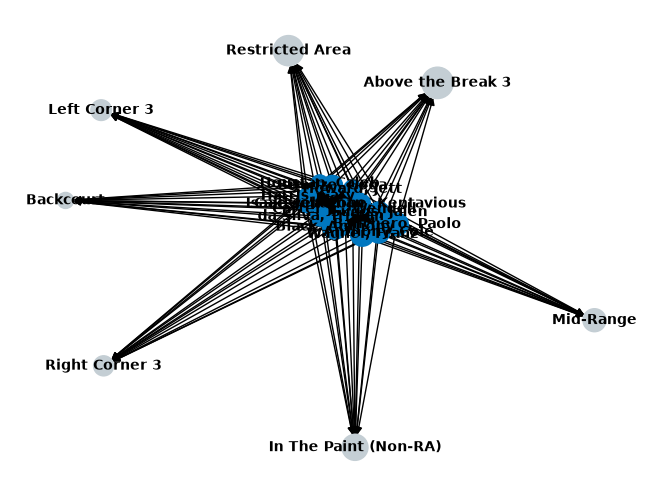

Processing team: Indiana Pacers
progress 18/30


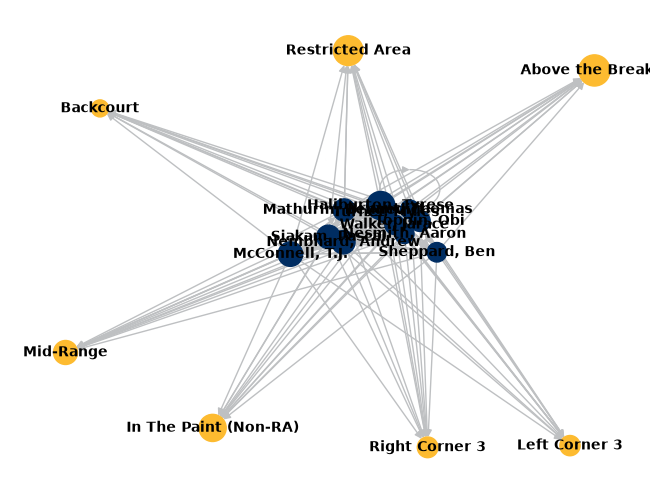

Processing team: Philadelphia 76ers
progress 19/30


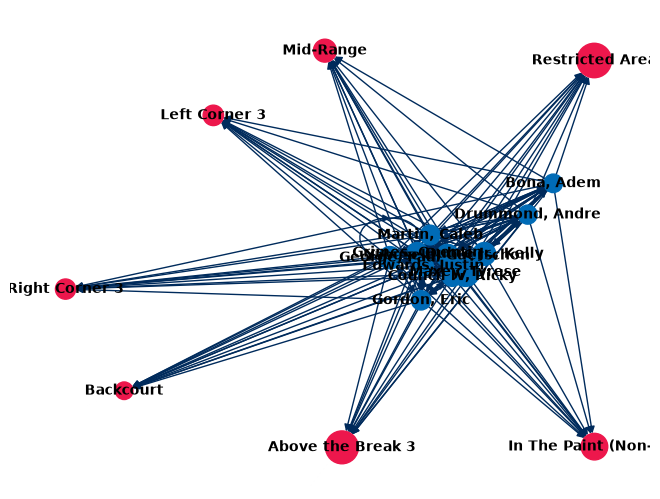

Processing team: Phoenix Suns
progress 20/30


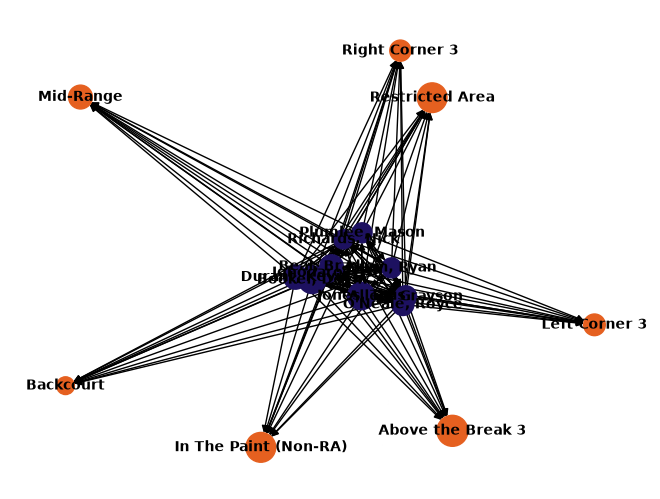

Processing team: Portland Trail Blazers
progress 21/30


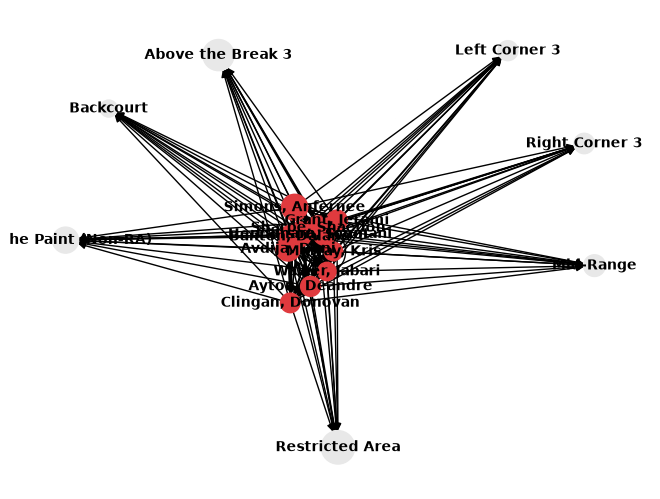

Processing team: Sacramento Kings
progress 22/30


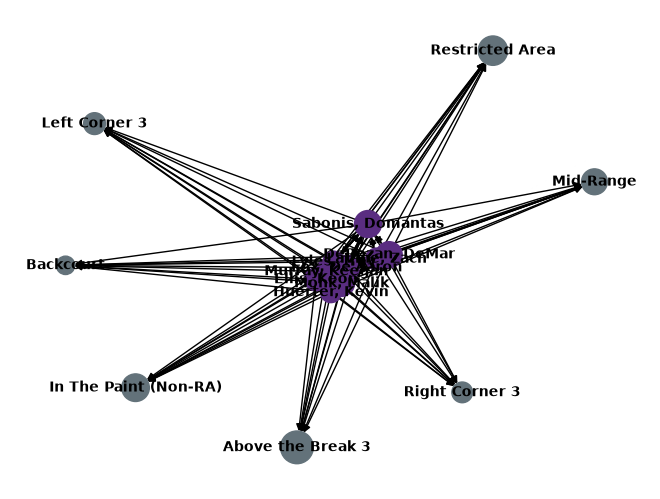

Processing team: San Antonio Spurs
progress 23/30


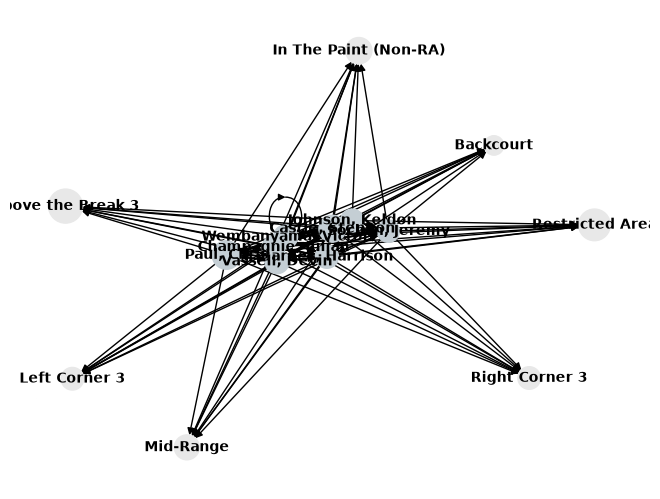

Processing team: Oklahoma City Thunder
progress 24/30


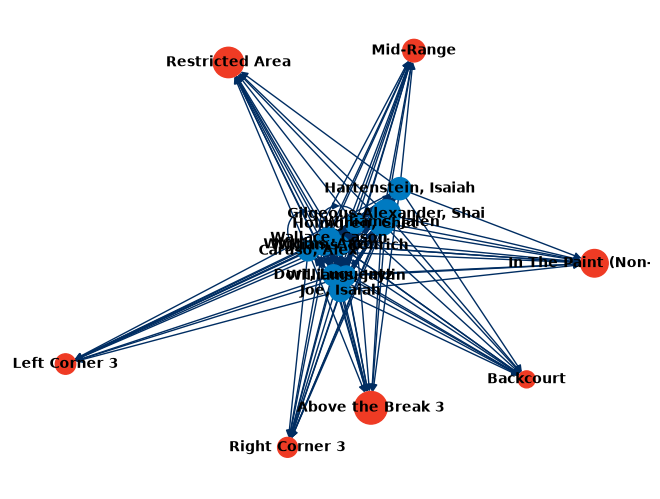

Processing team: Toronto Raptors
progress 25/30


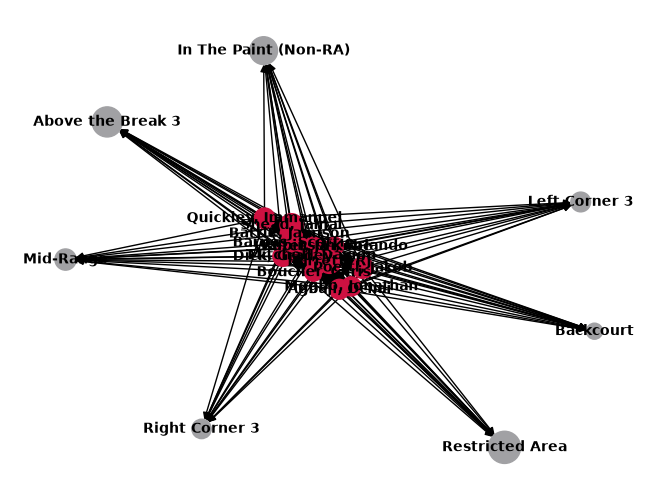

Processing team: Utah Jazz
progress 26/30


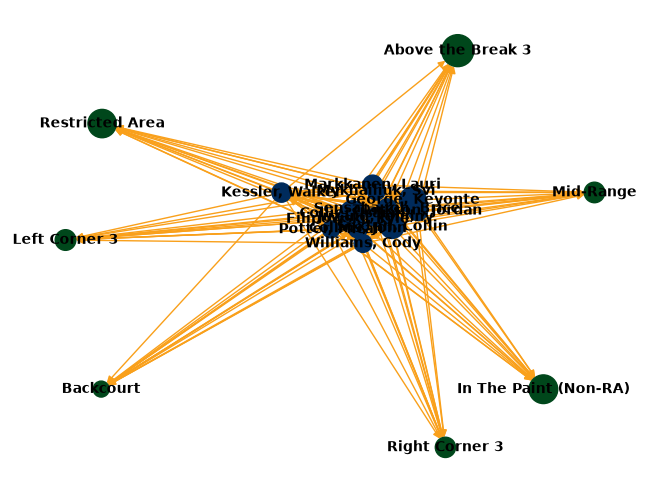

Processing team: Memphis Grizzlies
progress 27/30


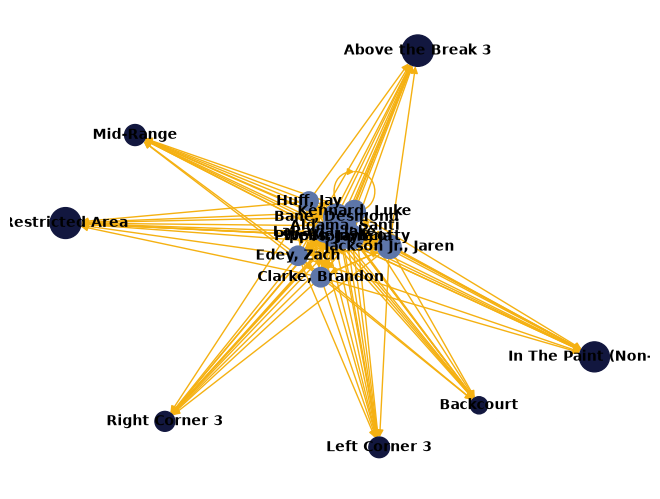

Processing team: Washington Wizards
progress 28/30


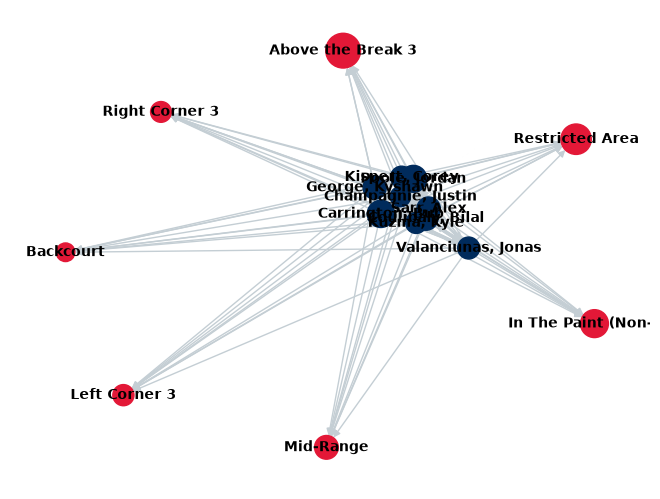

Processing team: Detroit Pistons
progress 29/30


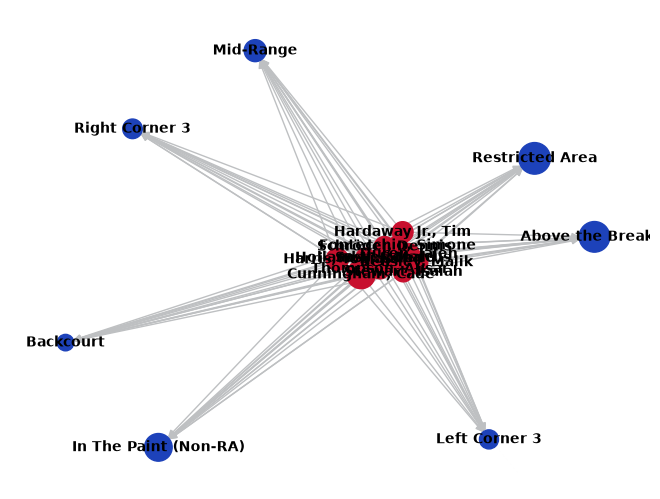

Processing team: Charlotte Hornets
progress 30/30


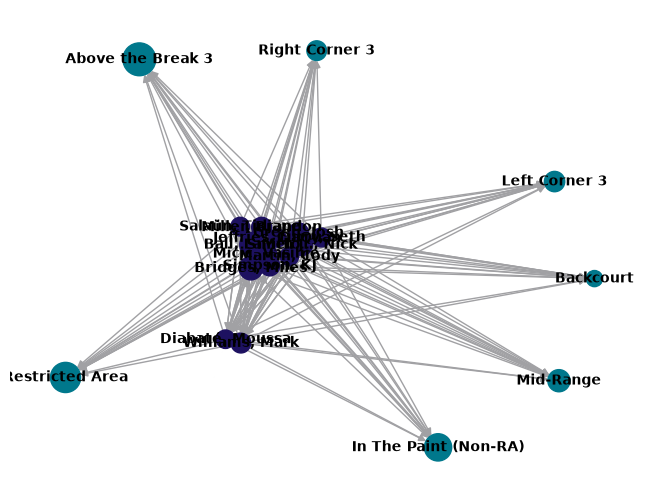

In [964]:
pageranks_fil = {}
count = 0

yr = '2024-25'

shots_24 = leaguedashplayershotlocations.LeagueDashPlayerShotLocations(season=yr, season_type_all_star='Regular Season').get_data_frames()[0]

for team in team_list:
    count += 1
    print(f"Processing team: {team['full_name']}")
    print(f"progress {count}/{len(team_list)}")
    
    team_df = get_team_df(team['id'],yr,filtered=True)
    team_pass_df = get_team_pass_df(team_df, team['id'], yr)
    
    #replacing nans with zero
    team_df.fillna(0, inplace=True)
    
    #getting total shots attempted for each player
    total_shots = team_df.iloc[:,2:16:2].sum(axis=1)
    
    #saftey to avoid division by zero
    total_shots = total_shots.replace(0, 1)
    
    #converting shot counts to proportions of total shots for each player
    prop_shots = team_df.iloc[:,2:16:2].div(total_shots, axis=0)

    team_to_id_map = pd.DataFrame({'player_id':team_pass_df['pass_to_id'].unique(), 'player_name': team_pass_df['pass_to'].unique()})

    prop_shots['player_id'] = team_df['player_id']
    prop_shots = pd.merge(prop_shots, team_to_id_map, on='player_id', how='left')
    prop_shots = prop_shots.iloc[:,[7,8,0,1,2,3,4,5,6]]
    G = nx.DiGraph()


    for _, row in team_pass_df.iterrows():
        G.add_edge(row['player_name'], row['pass_to'], weight=row['proportion'])

    for _, row in prop_shots.iterrows():
        for i, shot in enumerate(diff_shots):
            G.add_edge(row['player_name'], shot, weight=row.iloc[i+2])
        
    node_sizes = [list(nx.pagerank(G, weight="weight").items())[i][1]*5000 for i in range(len(list(nx.pagerank(G, weight="weight").items())))]
    node_colors = []
    nodes = list(G.nodes)
    for i in range(len(nodes)):
        if nodes[i] in diff_shots:
            node_colors.append(team_colors[team['full_name']][1])
        else:
            node_colors.append(team_colors[team['full_name']][0])

    nx.draw(G, with_labels=True, node_size=node_sizes, node_color=node_colors, font_size=10, font_weight='bold', edge_color=team_colors[team['full_name']][2])
    plt.show()

    pageranks_fil[team['full_name']] = sorted(nx.pagerank(G, weight="weight").items(), key=lambda x: x[1], reverse=True)
    time.sleep(10)  # Sleep for 10 seconds to avoid rate limiting
        

In [966]:
pageranks_fil['Atlanta Hawks']

[('Restricted Area', 0.10930869560568612),
 ('Above the Break 3', 0.10843697593427751),
 ('Young, Trae', 0.10341275926482421),
 ('In The Paint (Non-RA)', 0.09093868955041445),
 ('Daniels, Dyson', 0.06787211209627642),
 ('Johnson, Jalen', 0.05400288116856846),
 ('Okongwu, Onyeka', 0.05321437181522781),
 ('Right Corner 3', 0.05077807602686971),
 ('Risacher, Zaccharie', 0.0506718952371831),
 ('Krejčí, Vít', 0.049078168555328545),
 ('Mid-Range', 0.0490168705901444),
 ('Left Corner 3', 0.045925194293960976),
 ("Hunter, De'Andre", 0.04508147115240588),
 ('Capela, Clint', 0.0442204105220135),
 ('Mathews, Garrison', 0.042038084429231105),
 ('Backcourt', 0.036003343757587694)]

In [ ]:
pageranks_shots_fil_df = []
for team in pageranks_fil.keys():
    #normalizing pageranks to type of shots
    t_shots = sum([pageranks_fil[team][i][1] for i in range(len(pageranks_fil[team])) if pageranks_fil[team][i][0] in diff_shots])
    shot_prop = [pageranks_fil[team][i][1]/t_shots for i in range(len(pageranks_fil[team])) if pageranks_fil[team][i][0] in diff_shots]
    shot_label = [pageranks_fil[team][i][0] for i in range(len(pageranks_fil[team])) if pageranks_fil[team][i][0] in diff_shots]

    pageranks_shots_fil_df.append({'team': team, 'Restricted Area': shot_prop[shot_label.index('Restricted Area')], 'Paint': shot_prop[shot_label.index('In The Paint (Non-RA)')], 'Mid-Range': shot_prop[shot_label.index('Mid-Range')], 'Left Corner': shot_prop[shot_label.index('Left Corner 3')], 'Right Corner': shot_prop[shot_label.index('Right Corner 3')], 'Above Break': shot_prop[shot_label.index('Above the Break 3')], 'Backcourt': shot_prop[shot_label.index('Backcourt')]})

pageranks_shots_fil_df = pd.DataFrame(pageranks_shots_fil_df)

[('Restricted Area', 0.11121496269624694),
 ('Above the Break 3', 0.10316028421348636),
 ('In The Paint (Non-RA)', 0.08092692053479987),
 ('Curry, Stephen', 0.06855507614306545),
 ('Green, Draymond', 0.060737212853686204),
 ('Podziemski, Brandin', 0.05779305550673086),
 ('Hield, Buddy', 0.05246040255078768),
 ('Mid-Range', 0.0491316145818327),
 ('Butler III, Jimmy', 0.045922523098561346),
 ('Right Corner 3', 0.04572178248792089),
 ('Left Corner 3', 0.04559051083665984),
 ('Kuminga, Jonathan', 0.044696106032478464),
 ('Moody, Moses', 0.04464197999817576),
 ('Looney, Kevon', 0.04318907401435379),
 ('Payton II, Gary', 0.03992294654053408),
 ('Jackson-Davis, Trayce', 0.037800328592730095),
 ('Santos, Gui', 0.03742006563854345),
 ('Backcourt', 0.031115153679406)]